## Windkessel-Informed Neural Network for Cuffless BP Estimation 
==========================================================================

Physics constraint: 2-element Windkessel diastolic decay equation
 ##   DBP = SBP * exp(-decay_time / RC) ##
 
This constrains DBP to be consistent with the model's own SBP prediction
and the measured diastolic decay time (systolic peak -> dicrotic notch).
SBP remains purely data-driven (see explanation in accompanying chat message).
 
Sections:

    -  Peak / dicrotic notch detection  (feature extraction from raw PPG)

    -  RC estimation                    (fit once from training data)

    -  Windkessel physics loss          (the actual PINN constraint)

    - Model architecture               (simple 1D CNN)

    - Training loop                    (combines data loss + physics loss)

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.signal import (
    find_peaks,
    savgol_filter
)
import h5py

from tqdm import tqdm
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt

from torch.utils.data import Dataset, DataLoader

import sys
sys.path.append("..") 

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(device)

cuda


## Peak / Dicrotic Notch detection ##

Systolic peak = start of the "pressure is falling" phase, and dicrotic notch = the precise physiological start of diastole, where the heart is no longer pushing anything in.

For this eqn - P(t) = P_sys · exp(-t / RC)

We need t = decay time, which is simply the number of seconds it takes for arterial pressure to go from its systolic peak down to the start of the diastolic (passive) phase, measured as the time gap between the systolic peak and the dicrotic notch on the PPG waveform.

In [3]:
from PINN import prepare_UCI_dataset_w, get_dicrotic_notch, get_systolic_peak, get_delay_time, estimate_RC, grid_search_RC, train_resnet1d, create_data_loaders, run_windkessel_pinn, plot_training_loss,plot_pinn_training_metrics

In [4]:
wavelet = "coif5"
level = 5
DATA_PATH = (f"/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/PINN/wavelets_data/{wavelet}_{level}")

MAT_PATH = f"/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/PINN/wavelets_data/{wavelet}_{level}/Part_1.mat"

In [5]:
FS = 125
WINDOW_SIZE = 1000


f = h5py.File(MAT_PATH, "r")

dataset = f["Part_1"]

# print("Number of recordings:", dataset.shape[0])
ref = dataset[1,0 ]

recording = f[ref][:]

print("Recording shape:", recording.shape)
ppg = recording[:, 0]
abp = recording[:, 1]

print("PPG length:", len(ppg))
print("ABP length:", len(abp))
ppg_std = np.std(ppg)


ppg = (ppg - np.mean(ppg)) / ppg_std # Normalize PPG signal
START = 0

ppg_window = ppg[
    START:START + WINDOW_SIZE
]

print("Window shape:", ppg_window.shape)


# ==========================================
# Detect ALL systolic peaks
# ==========================================

sys_peaks = get_systolic_peak(
    ppg_window,
    FS
)

print(
    "Number of systolic peaks:",
    len(sys_peaks)
)

print(
    "Systolic peak indices:",
    sys_peaks
)


# ==========================================
# Find notch after EACH systolic peak
# ==========================================
def calculate_derivatives(ppg, fs=125):

    # -----------------------------------
    # Smooth PPG
    # -----------------------------------

    smooth_ppg = savgol_filter(
        ppg,
        window_length=15,
        polyorder=3
    )

    # -----------------------------------
    # First derivative = VPG
    # -----------------------------------

    vpg = np.gradient(
        smooth_ppg
    ) * fs

    # -----------------------------------
    # Second derivative = APG
    # -----------------------------------

    apg = np.gradient(
        vpg
    ) * fs

    return smooth_ppg, vpg, apg
notches = []

for sys_idx in sys_peaks:
    smooth_ppg, vpg, apg = calculate_derivatives(
            ppg_window,
            FS
        )
    

    notch_idx = get_dicrotic_notch(
        ppg_window,
        sys_idx,
        vpg,
        apg,
        FS
    )

    notches.append(notch_idx)


# ==========================================
# Print results
# ==========================================

print("\nDetected landmarks:")

for i, (sys_idx, notch_idx) in enumerate(
    zip(sys_peaks, notches)
):

    print(
        f"Beat {i+1}: "
        f"Systolic = {sys_idx} "
        f"({sys_idx / FS:.3f} s), "
        f"Notch = {notch_idx}"
    )


delay_times = []

for sys_idx, notch_idx in zip(
    sys_peaks,
    notches
):

    if notch_idx is None:
        delay_times.append(np.nan)

    else:

        delay = (
            notch_idx - sys_idx
        ) / FS

        delay_times.append(delay)


delay_times = np.array(
    delay_times,
    dtype=np.float32
)


print("\nPeak → notch delays:")

for i, delay in enumerate(delay_times):

    if np.isnan(delay):

        print(
            f"Beat {i+1}: Detection failed"
        )

    else:

        print(
            f"Beat {i+1}: "
            f"{delay:.3f} seconds"
        )


Recording shape: (61000, 3)
PPG length: 61000
ABP length: 61000
Window shape: (1000,)
Number of systolic peaks: 15
Systolic peak indices: [ 57 122 187 251 314 379 444 508 571 635 700 763 825 889 953]

Detected landmarks:
Beat 1: Systolic = 57 (0.456 s), Notch = 73
Beat 2: Systolic = 122 (0.976 s), Notch = 138
Beat 3: Systolic = 187 (1.496 s), Notch = 203
Beat 4: Systolic = 251 (2.008 s), Notch = 267
Beat 5: Systolic = 314 (2.512 s), Notch = 333
Beat 6: Systolic = 379 (3.032 s), Notch = 397
Beat 7: Systolic = 444 (3.552 s), Notch = 461
Beat 8: Systolic = 508 (4.064 s), Notch = 525
Beat 9: Systolic = 571 (4.568 s), Notch = 588
Beat 10: Systolic = 635 (5.080 s), Notch = 652
Beat 11: Systolic = 700 (5.600 s), Notch = 716
Beat 12: Systolic = 763 (6.104 s), Notch = 782
Beat 13: Systolic = 825 (6.600 s), Notch = 842
Beat 14: Systolic = 889 (7.112 s), Notch = 907
Beat 15: Systolic = 953 (7.624 s), Notch = 970

Peak → notch delays:
Beat 1: 0.128 seconds
Beat 2: 0.128 seconds
Beat 3: 0.128 secon

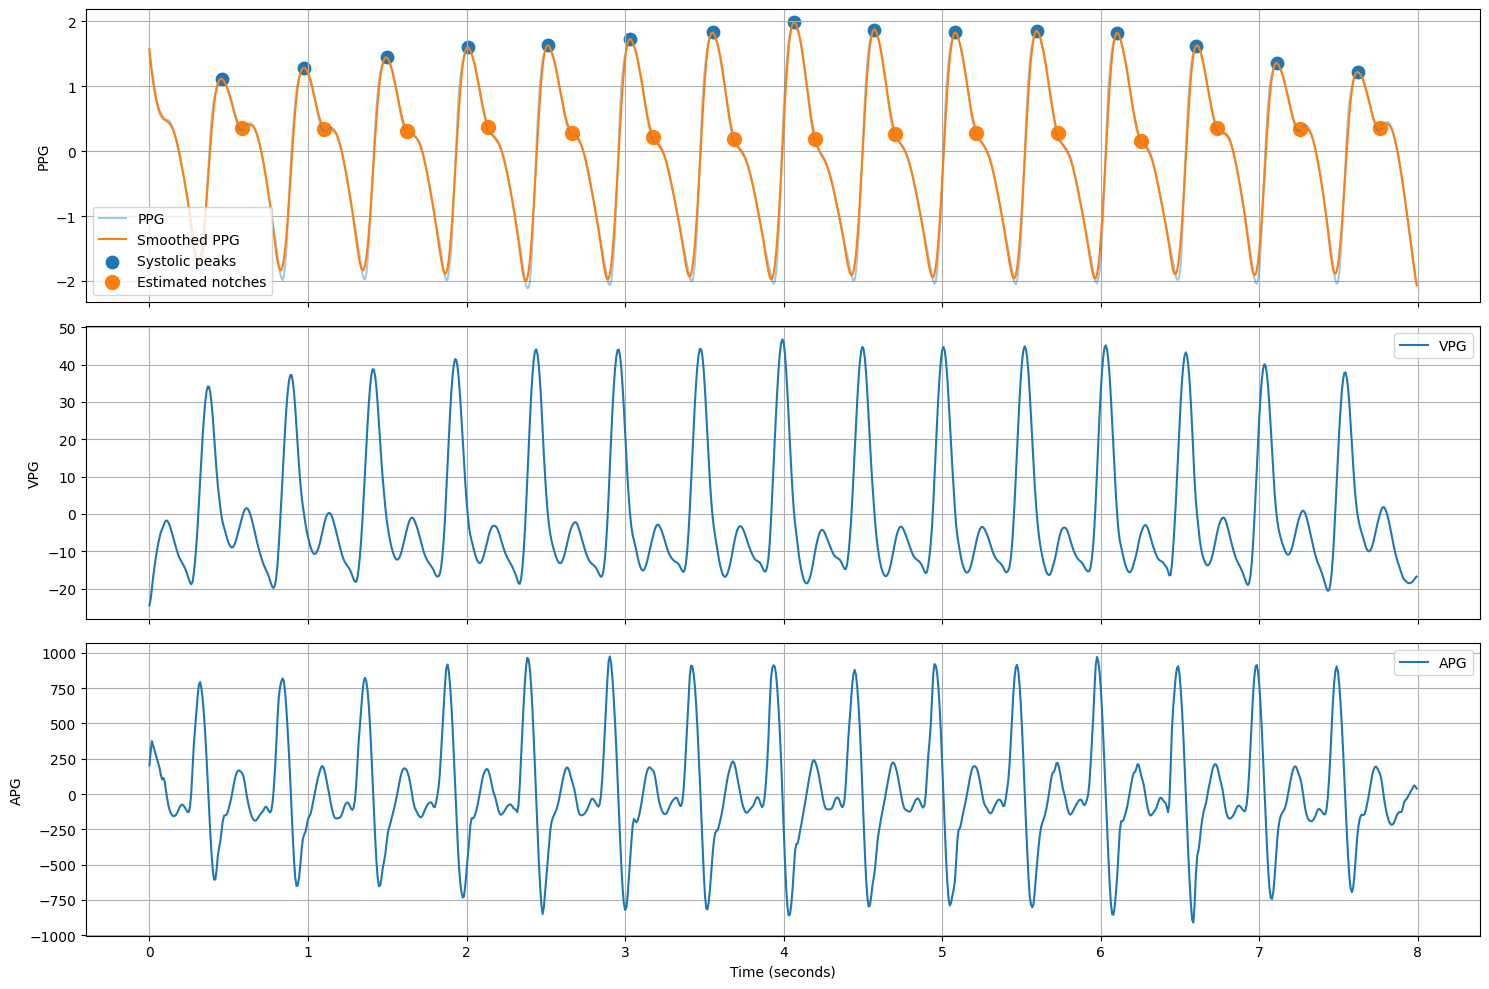

In [6]:
smooth_ppg = savgol_filter(
    ppg_window,
    window_length=21,
    polyorder=3
)
vpg = np.gradient(smooth_ppg) * FS
apg = np.gradient(vpg) * FS


time = np.arange(
    len(ppg_window)
) / FS

fig, axes = plt.subplots(
    3,
    1,
    figsize=(15, 10),
    sharex=True
)


# ==================================================
# PPG
# ==================================================

axes[0].plot(
    time,
    ppg_window,
    alpha=0.4,
    label="PPG"
)

axes[0].plot(
    time,
    smooth_ppg,
    label="Smoothed PPG"
)


# All systolic peaks

axes[0].scatter(
    sys_peaks / FS,
    smooth_ppg[sys_peaks],
    s=80,
    label="Systolic peaks"
)


# All detected notches

valid_notches = [
    n for n in notches
    if n is not None
]

if len(valid_notches) > 0:

    valid_notches = np.array(
        valid_notches,
        dtype=int
    )

    axes[0].scatter(
        valid_notches / FS,
        smooth_ppg[valid_notches],
        s=100,
        label="Estimated notches"
    )


axes[0].set_ylabel("PPG")
axes[0].legend()
axes[0].grid()


# ==================================================
# VPG
# ==================================================

axes[1].plot(
    time,
    vpg,
    label="VPG"
)

axes[1].set_ylabel("VPG")
axes[1].legend()
axes[1].grid()


# ==================================================
# APG
# ==================================================

axes[2].plot(
    time,
    apg,
    label="APG"
)

axes[2].set_xlabel("Time (seconds)")
axes[2].set_ylabel("APG")
axes[2].legend()
axes[2].grid()


plt.tight_layout()
plt.show()

In [7]:
delay_time =  get_delay_time(ppg_window)
print(delay_time)

[0.128 0.128 0.128 0.128 0.152 0.144 0.136 0.136 0.136 0.136 0.128 0.152
 0.136 0.144 0.136]


In [8]:
X_train, y_train, delay_train, X_val, y_val, delay_val, X_test, y_test, delay_test = prepare_UCI_dataset_w(
    data_path=DATA_PATH, window_size=1000, step_size=1000)

Total recordings: 12000
Train recordings: 8400
Validation recordings: 1200
Test recordings: 2400

Processing TRAIN recordings...


Processing recordings: 100%|██████████| 8400/8400 [07:45<00:00, 18.06it/s]


Skipped recordings: 94

Processing VALIDATION recordings...


Processing recordings: 100%|██████████| 1200/1200 [01:07<00:00, 17.74it/s]


Skipped recordings: 14

Processing TEST recordings...


Processing recordings: 100%|██████████| 2400/2400 [02:17<00:00, 17.42it/s]


Skipped recordings: 16

DATASET SHAPES
X_train: torch.Size([229144, 1, 1000])
y_train: torch.Size([229144, 2])
delay_train: torch.Size([229144])
X_val: torch.Size([32981, 1, 1000])
y_val: torch.Size([32981, 2])
delay_val: torch.Size([32981])
X_test: torch.Size([67291, 1, 1000])
y_test: torch.Size([67291, 2])
delay_test: torch.Size([67291])


In [9]:
print("Shape:", delay_train.shape)
print("Dtype:", delay_train.dtype)
print("NaN count:", np.isnan(delay_train).sum())
delay_train_np = delay_train.detach().cpu().numpy().astype(np.float32)
print(
    "NaN percentage:",
    100 * np.isnan(delay_train_np).mean(),
    "%"
)

valid_delay = delay_train_np[
    np.isfinite(delay_train_np)
]

print("Valid values:", len(valid_delay))

if len(valid_delay) > 0:

    print("\nStatistics:")

    print(
        "Min    :",
        np.min(valid_delay)
    )

    print(
        "Max    :",
        np.max(valid_delay)
    )

    print(
        "Mean   :",
        np.mean(valid_delay)
    )

    print(
        "Median :",
        np.median(valid_delay)
    )

    print(
        "Std    :",
        np.std(valid_delay)
    )

if len(valid_delay) > 0:

    print("\nRange checks:")

    print(
        "Below 0.08 s:",
        np.sum(valid_delay < 0.08)
    )

    print(
        "Above 0.35 s:",
        np.sum(valid_delay > 0.35)
    )

    print(
        "Within 0.08–0.35 s:",
        np.sum(
            (valid_delay >= 0.08) &
            (valid_delay <= 0.35)
        )
    )


if len(valid_delay) > 0:

    print("\nPercentiles:")

    for p in [1, 5, 25, 50, 75, 95, 99]:

        print(
            f"{p:2d}% :",
            np.percentile(valid_delay, p)
        )

Shape: torch.Size([229144])
Dtype: torch.float32
NaN count: tensor(0)
NaN percentage: 0.0 %
Valid values: 229144

Statistics:
Min    : 0.096
Max    : 0.336
Mean   : 0.18805762
Median : 0.184
Std    : 0.030446434

Range checks:
Below 0.08 s: 0
Above 0.35 s: 0
Within 0.08–0.35 s: 229144

Percentiles:
 1% : 0.128
 5% : 0.144
25% : 0.168
50% : 0.184
75% : 0.204
95% : 0.24
99% : 0.296


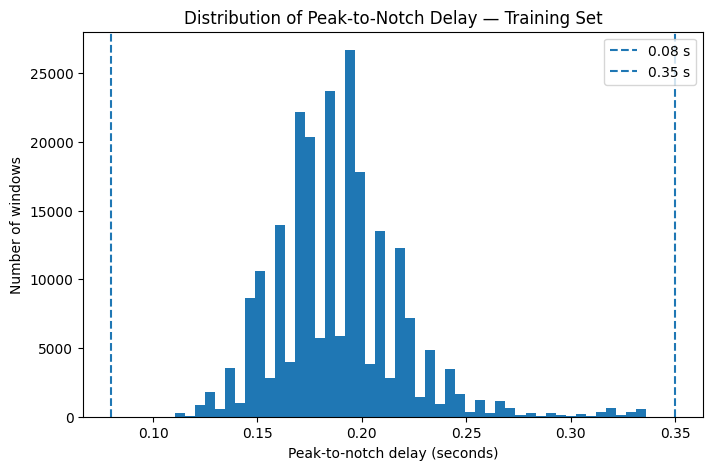

In [10]:
import matplotlib.pyplot as plt

valid_delay = delay_train[
    np.isfinite(delay_train)
]

plt.figure(figsize=(8, 5))

plt.hist(
    valid_delay,
    bins=50
)

plt.xlabel("Peak-to-notch delay (seconds)")
plt.ylabel("Number of windows")
plt.title("Distribution of Peak-to-Notch Delay — Training Set")

plt.axvline(
    0.08,
    linestyle="--",
    label="0.08 s"
)

plt.axvline(
    0.35,
    linestyle="--",
    label="0.35 s"
)

plt.legend()

plt.show()

In [11]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("delay_train:", delay_train.shape)

print(
    "Number of windows:",
    len(X_train)
)

print(
    "Number of BP labels:",
    len(y_train)
)

print(
    "Number of delays:",
    len(delay_train)
)

X_train: torch.Size([229144, 1, 1000])
y_train: torch.Size([229144, 2])
delay_train: torch.Size([229144])
Number of windows: 229144
Number of BP labels: 229144
Number of delays: 229144


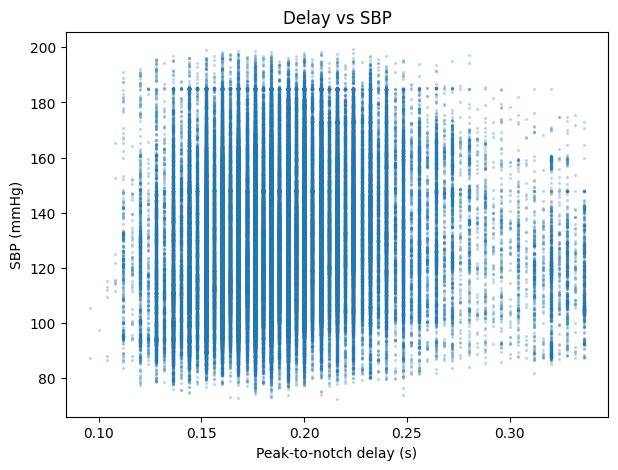

In [12]:
plt.figure(figsize=(7, 5))

plt.scatter(
    valid_delay,
    y_train[np.isfinite(delay_train), 0],
    s=2,
    alpha=0.2
)

plt.xlabel("Peak-to-notch delay (s)")
plt.ylabel("SBP (mmHg)")
plt.title("Delay vs SBP")

plt.show()

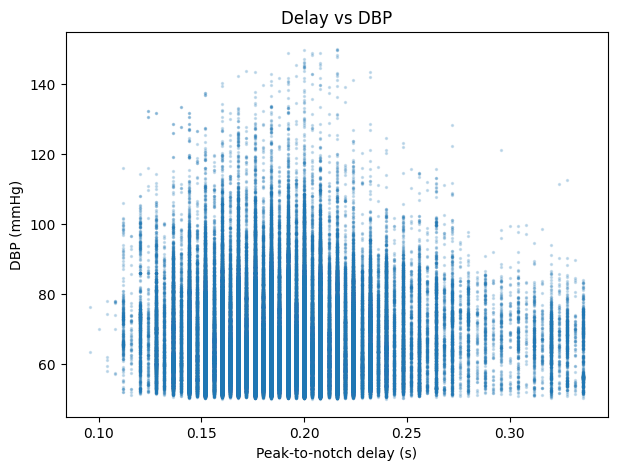

In [13]:
plt.figure(figsize=(7, 5))

plt.scatter(
    valid_delay,
    y_train[np.isfinite(delay_train), 1],
    s=2,
    alpha=0.2
)

plt.xlabel("Peak-to-notch delay (s)")
plt.ylabel("DBP (mmHg)")
plt.title("Delay vs DBP")

plt.show()

## RC Estimation ##

In [14]:
RC, RC_values = estimate_RC(
    sbp=y_train[:, 0].numpy(),
    dbp=y_train[:, 1].numpy(),
    delay=delay_train
)

Total windows: 229144
Valid windows: 229144
Valid percentage: 100.0 %

Windkessel RC Estimation
Median RC : 0.2788 s
Mean RC   : 0.2997 s
Std RC    : 0.1033 s
Min RC    : 0.1022 s
Max RC    : 1.5168 s


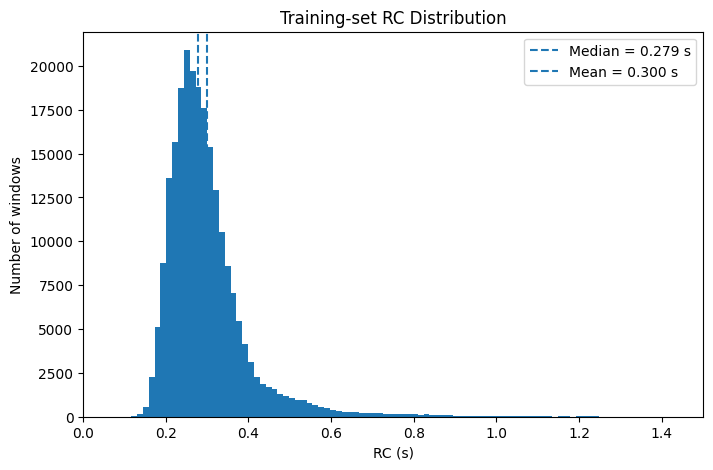

In [15]:
plt.figure(figsize=(8, 5))

plt.hist(
    RC_values,
    bins=100
)

plt.axvline(
    np.median(RC_values),
    linestyle="--",
    label=f"Median = {np.median(RC_values):.3f} s"
)
plt.axvline(
    np.mean(RC_values),
    linestyle="--",
    label=f"Mean = {np.mean(RC_values):.3f} s"
)

plt.xlabel("RC (s)")
plt.xlim(0,1.5)
plt.ylabel("Number of windows")
plt.title("Training-set RC Distribution")
plt.legend()

plt.show()

It's a highly skewed distribution, so using mean won't be a good idea

In [16]:
for p in [1, 5, 25, 50, 75, 90, 95, 99, 99.5, 99.9]:
    print(
        f"{p:5.1f}% : "
        f"{np.percentile(RC_values, p):.4f} s"
    )

  1.0% : 0.1696 s
  5.0% : 0.1934 s
 25.0% : 0.2382 s
 50.0% : 0.2788 s
 75.0% : 0.3306 s
 90.0% : 0.4003 s
 95.0% : 0.4826 s
 99.0% : 0.7271 s
 99.5% : 0.8431 s
 99.9% : 1.0917 s


In [17]:
RC = 0.2994

sbp = y_train[:, 0].cpu().numpy()
dbp = y_train[:, 1].cpu().numpy()
delay = delay_train.cpu().numpy()

dbp_physics = (
    sbp *
    np.exp(-delay / RC)
)

physics_mae = np.mean(
    np.abs(dbp_physics - dbp)
)

physics_rmse = np.sqrt(
    np.mean(
        (dbp_physics - dbp) ** 2
    )
)

print("Physics-only DBP MAE :", physics_mae)
print("Physics-only DBP RMSE:", physics_rmse)

Physics-only DBP MAE : 9.493763
Physics-only DBP RMSE: 12.296519


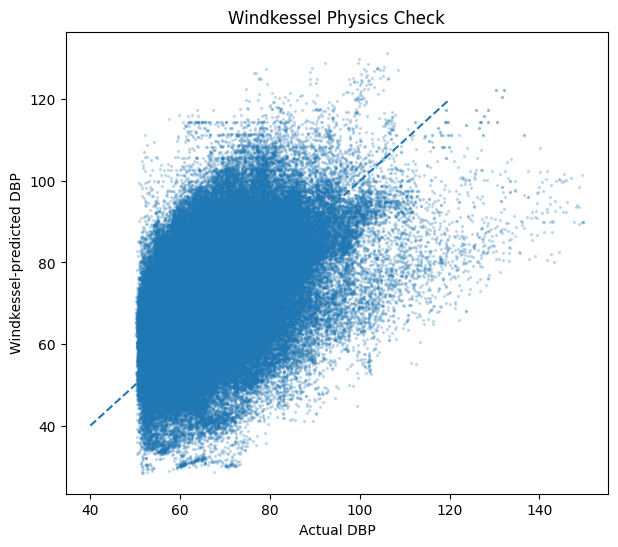

In [18]:
plt.figure(figsize=(7, 6))

plt.scatter(
    dbp,
    dbp_physics,
    s=2,
    alpha=0.2
)

plt.plot(
    [40, 120],
    [40, 120],
    linestyle="--"
)

plt.xlabel("Actual DBP")
plt.ylabel("Windkessel-predicted DBP")
plt.title("Windkessel Physics Check")

plt.show()

In [19]:
rc_values, mae_values, rmse_values, best_RC_MAE, best_RC_RMSE = grid_search_RC(
    sbp=y_train[:, 0].cpu().numpy(),
    dbp=y_train[:, 1].cpu().numpy(),
    delay=delay_train.cpu().numpy(),
    rc_min=0.10,
    rc_max=1.00,
    rc_step=0.005
)
RC = best_RC_MAE

Valid samples: 229144

RC GRID SEARCH RESULTS
Best RC by MAE  : 0.2750 s
Best MAE        : 9.0040 mmHg

Best RC by RMSE : 0.2750 s
Best RMSE       : 11.7688 mmHg


## Establishing Baseline using 1D ResNet ##

In [20]:
import random
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# ============================================================
# Device
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

Device: cuda


In [21]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: torch.Size([229144, 1, 1000])
y_train: torch.Size([229144, 2])
X_val: torch.Size([32981, 1, 1000])
y_val: torch.Size([32981, 2])
X_test: torch.Size([67291, 1, 1000])
y_test: torch.Size([67291, 2])


In [22]:
train_loader, val_loader, test_loader = create_data_loaders(
    X_train, y_train,
    X_val, y_val,  
    X_test, y_test)


Epoch [01/50] LR: 1.00e-04 | Train MSE: 7675.7455 | Train SBP MSE: 12663.9377 | Train DBP MSE: 2687.5534 | Train SBP RMSE: 112.5342 | Train DBP RMSE: 51.8416 | Val MSE: 4753.2486 | Val SBP MSE: 8457.6000 | Val DBP MSE: 1048.8972 | Val SBP RMSE: 91.9652 | Val DBP RMSE: 32.3867
Epoch [02/50] LR: 1.00e-04 | Train MSE: 2849.0851 | Train SBP MSE: 5257.5248 | Train DBP MSE: 440.6454 | Train SBP RMSE: 72.5088 | Train DBP RMSE: 20.9916 | Val MSE: 1223.2123 | Val SBP MSE: 2335.2602 | Val DBP MSE: 111.1642 | Val SBP RMSE: 48.3245 | Val DBP RMSE: 10.5434
Epoch [03/50] LR: 1.00e-04 | Train MSE: 691.6291 | Train SBP MSE: 1260.2170 | Train DBP MSE: 123.0412 | Train SBP RMSE: 35.4995 | Train DBP RMSE: 11.0924 | Val MSE: 282.3657 | Val SBP MSE: 442.8006 | Val DBP MSE: 121.9309 | Val SBP RMSE: 21.0428 | Val DBP RMSE: 11.0422
Epoch [04/50] LR: 1.00e-04 | Train MSE: 269.1713 | Train SBP MSE: 424.7317 | Train DBP MSE: 113.6108 | Train SBP RMSE: 20.6090 | Train DBP RMSE: 10.6588 | Val MSE: 247.3696 | Val S

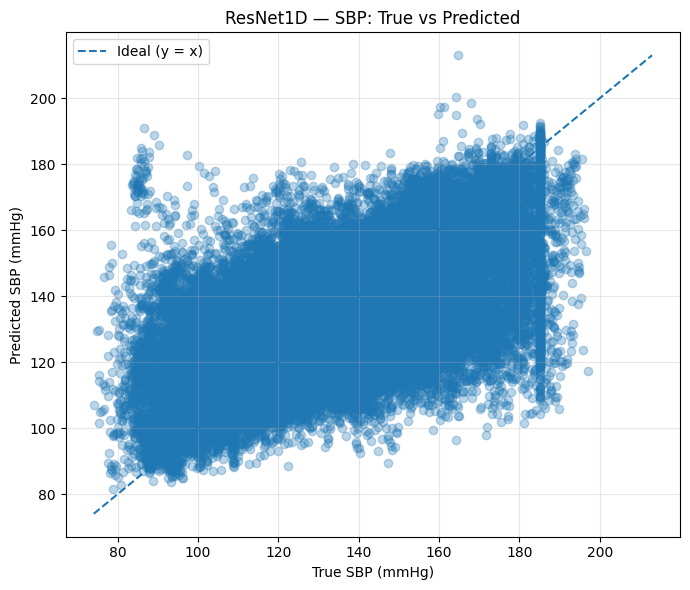

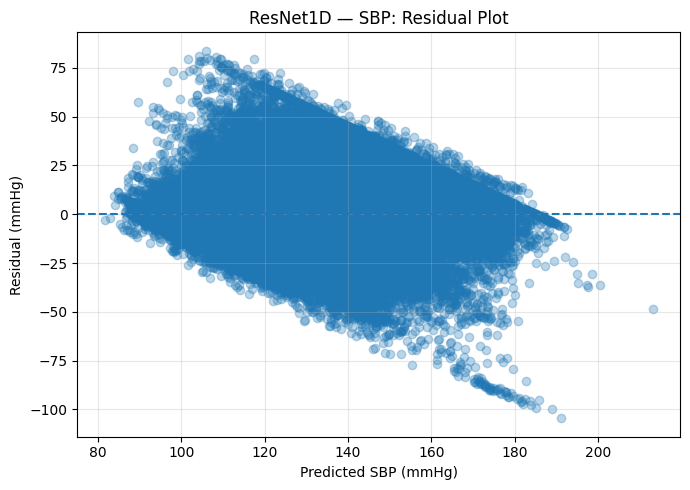

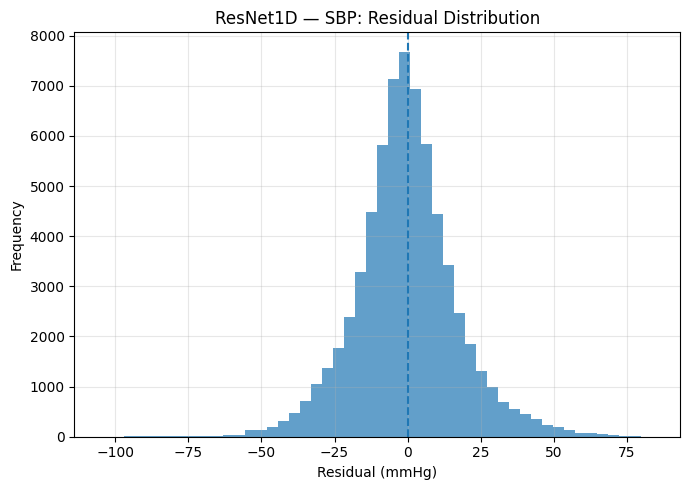

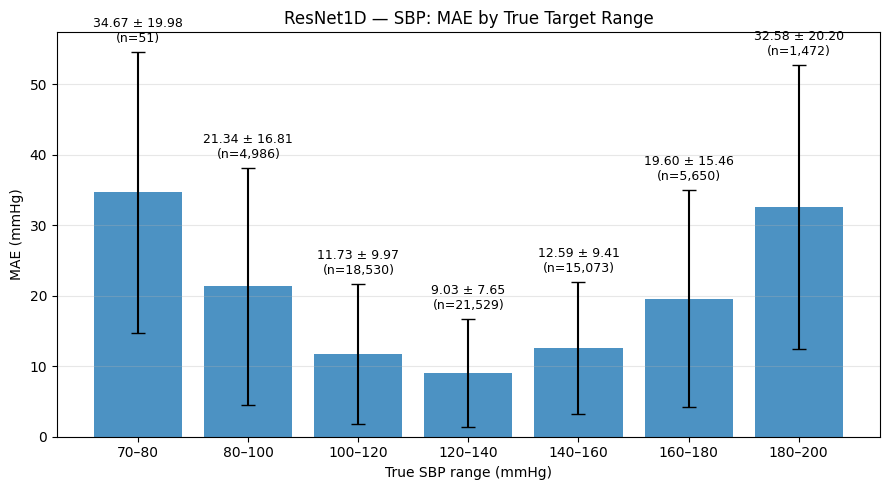



DBP TEST RESULTS
RMSE: 9.2089
MSE : 84.8035
R²  : 0.3163
MAE : 6.4776


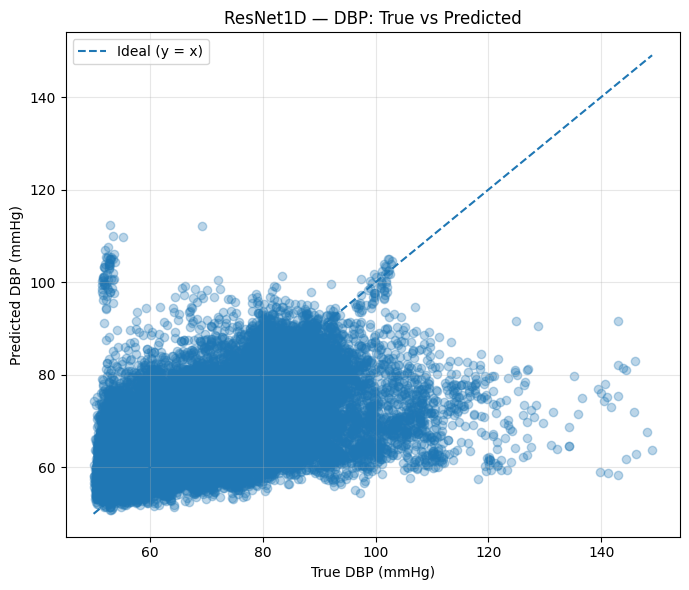

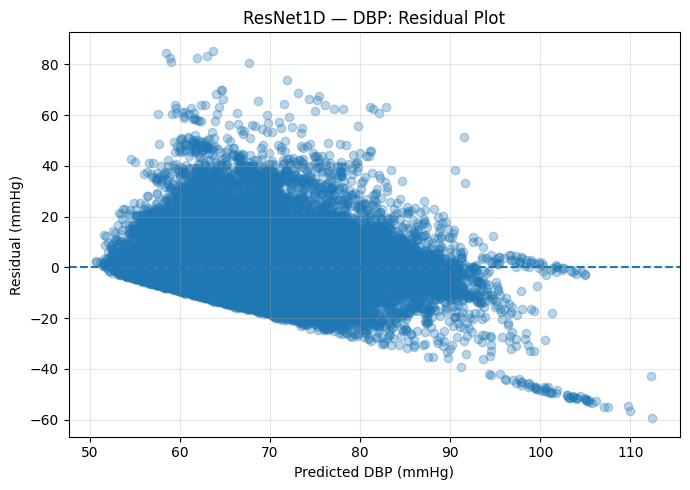

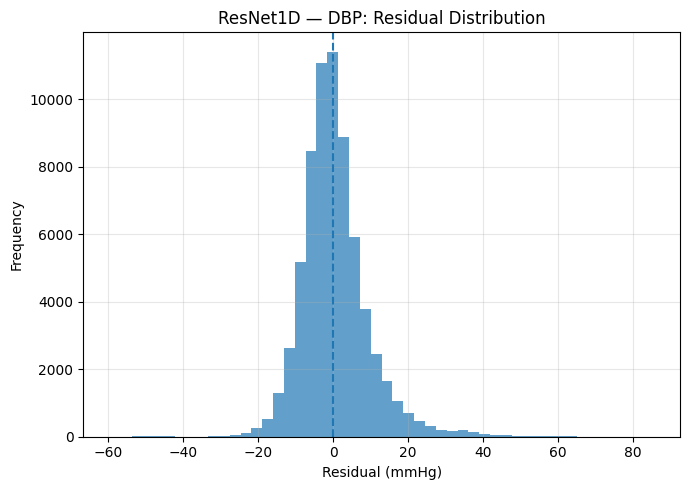

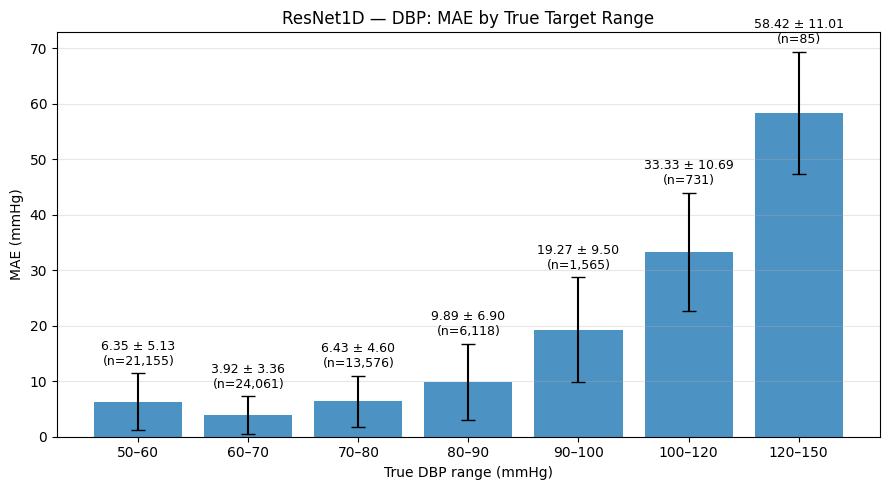

In [23]:
model, history, y_true, y_pred = train_resnet1d(
    train_loader,
    val_loader,
    test_loader,
    device,
    epochs=50
)

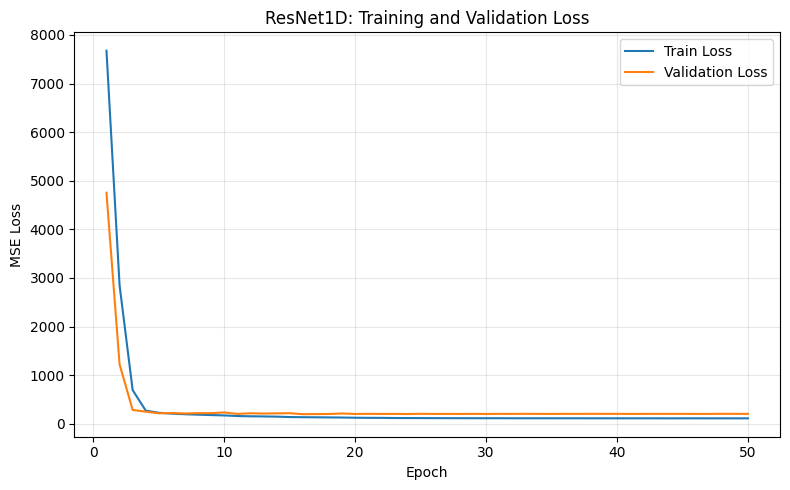

In [24]:
plot_training_loss(
    history,
    model_name="ResNet1D"
)

## Physics Informed Windkessel ##

Epoch [001/50] | LR: 1.00e-04 | Train Total: 15784.6137 | Train SBP MSE: 12968.8606 | Train DBP MSE: 2815.7477 | Train Phys: 54.8770 | Train RMSE: SBP=113.881, DBP=53.064 | Val Total: 9952.2499 | Val SBP MSE: 8785.8590 | Val DBP MSE: 1166.3704 | Val Phys: 203.8348 | Val RMSE: SBP=93.733, DBP=34.152 | ✓
Epoch [002/50] | LR: 1.00e-04 | Train Total: 6108.2897 | Train SBP MSE: 5606.2173 | Train DBP MSE: 502.0337 | Train Phys: 387.7797 | Train RMSE: SBP=74.875, DBP=22.406 | Val Total: 2736.6306 | Val SBP MSE: 2628.0143 | Val DBP MSE: 108.5710 | Val Phys: 452.3887 | Val RMSE: SBP=51.264, DBP=10.420 | ✓
Epoch [003/50] | LR: 1.00e-04 | Train Total: 1247.0722 | Train SBP MSE: 1132.4718 | Train DBP MSE: 114.5765 | Train Phys: 238.9878 | Train RMSE: SBP=33.652, DBP=10.704 | Val Total: 715.4081 | Val SBP MSE: 607.1093 | Val DBP MSE: 108.2922 | Val Phys: 66.3847 | Val RMSE: SBP=24.640, DBP=10.406 | ✓
Epoch [004/50] | LR: 1.00e-04 | Train Total: 486.3685 | Train SBP MSE: 376.7597 | Train DBP MSE: 10

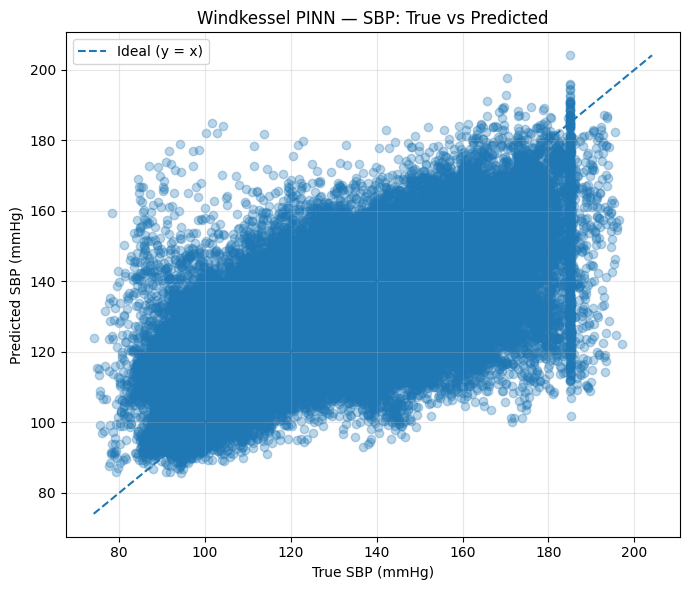

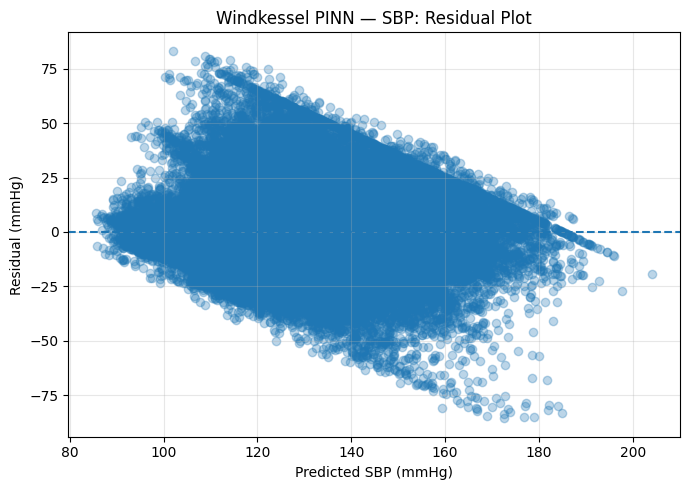

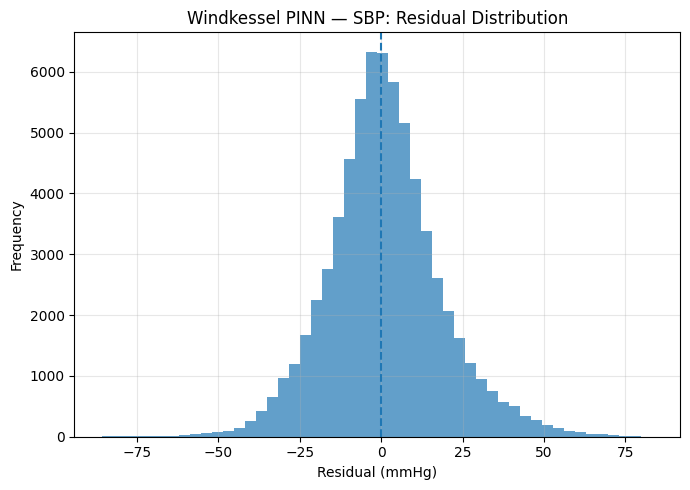

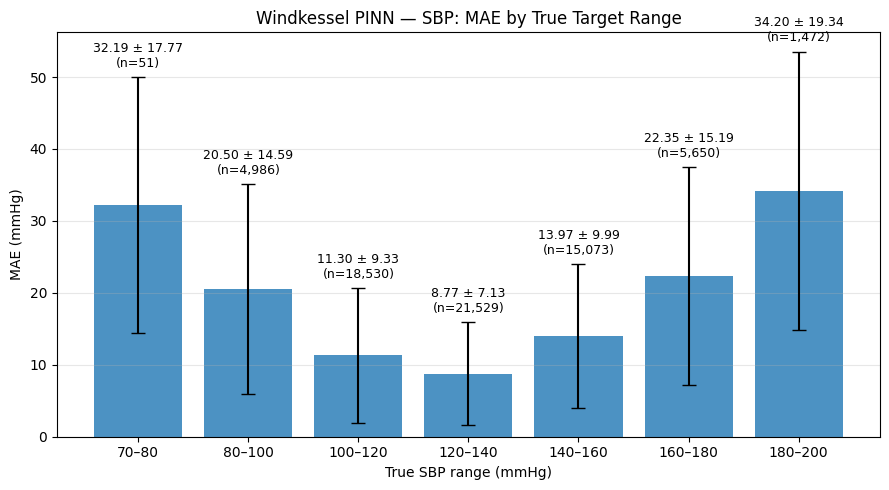


WINDKESSEL PINN — DBP TEST RESULTS
RMSE: 9.1401
MSE : 83.5413
R²  : 0.3264
MAE : 6.5159


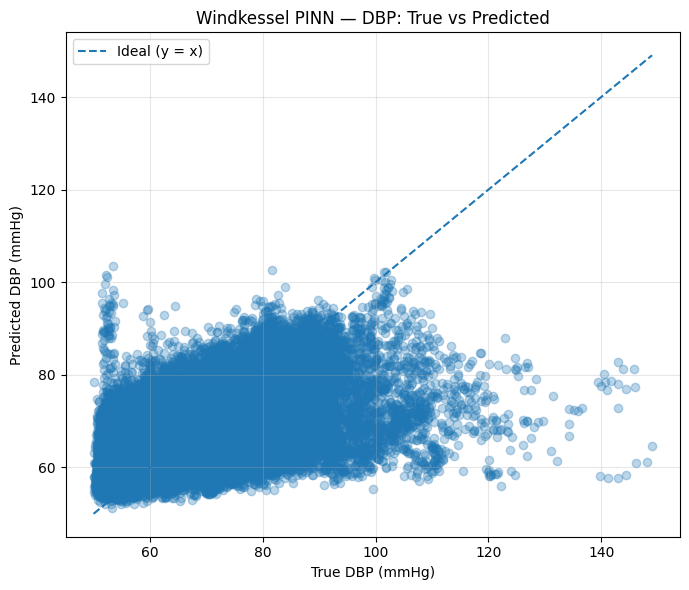

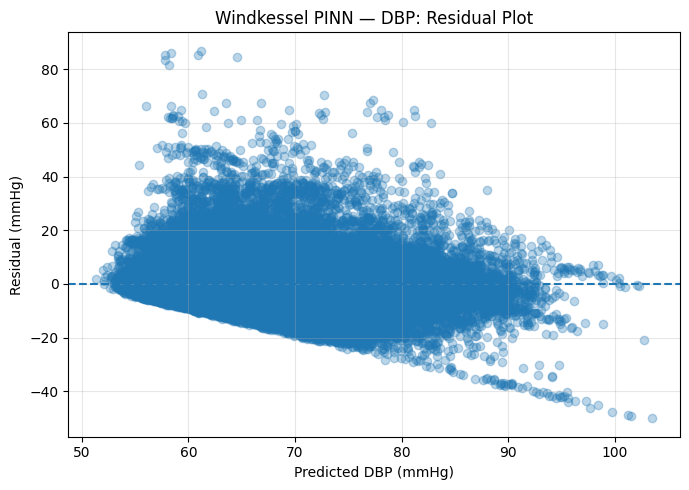

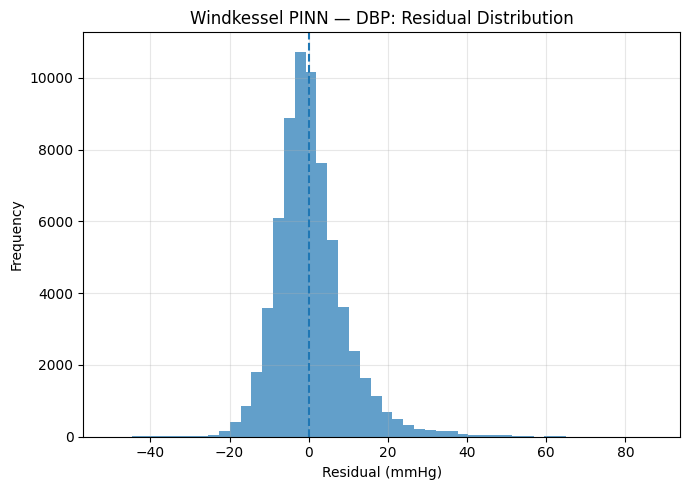

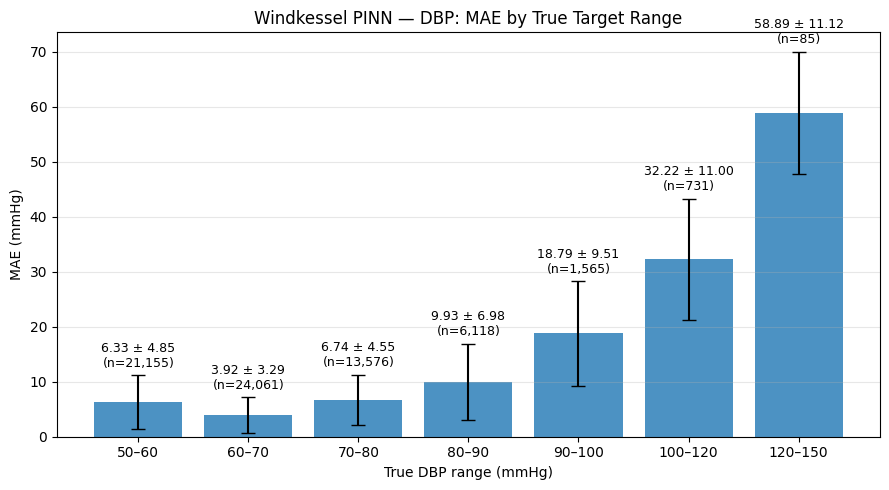

In [25]:
model, results = run_windkessel_pinn(
    X_train, y_train, delay_train,
    X_val, y_val, delay_val,
    X_test, y_test, delay_test,
    RC=RC,
    device=device,
    lambda_phys=0.0001
)

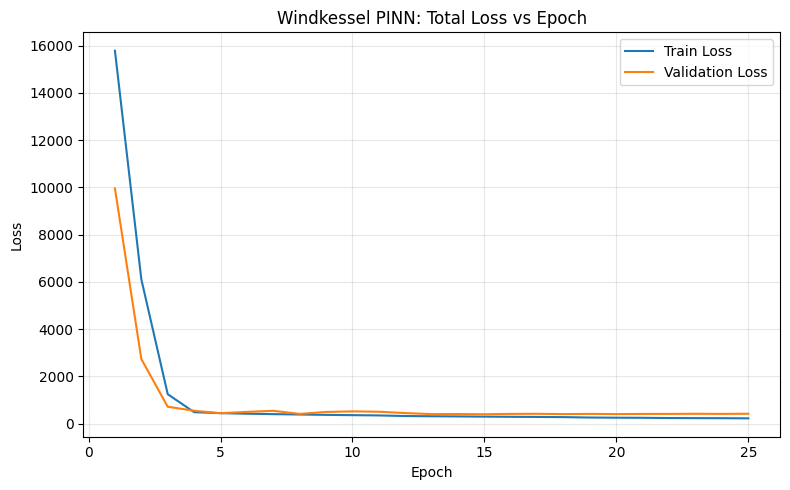

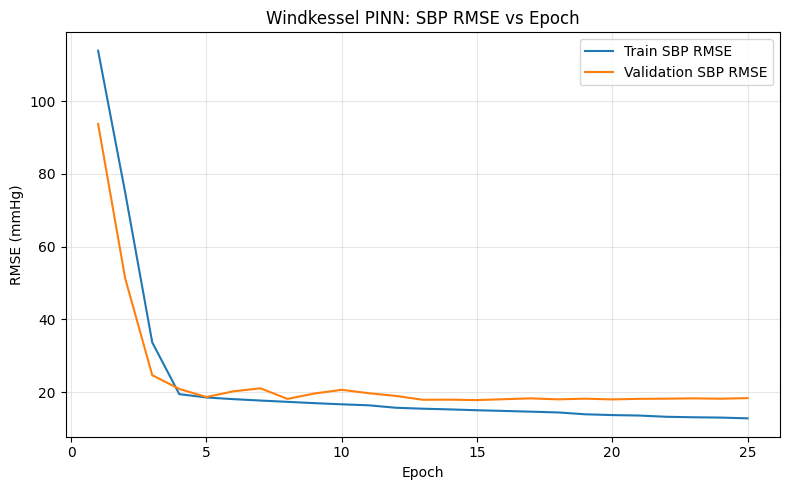

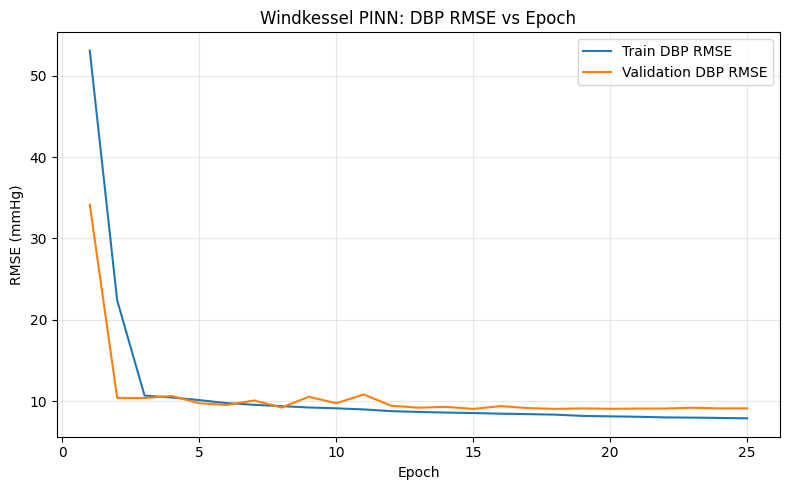

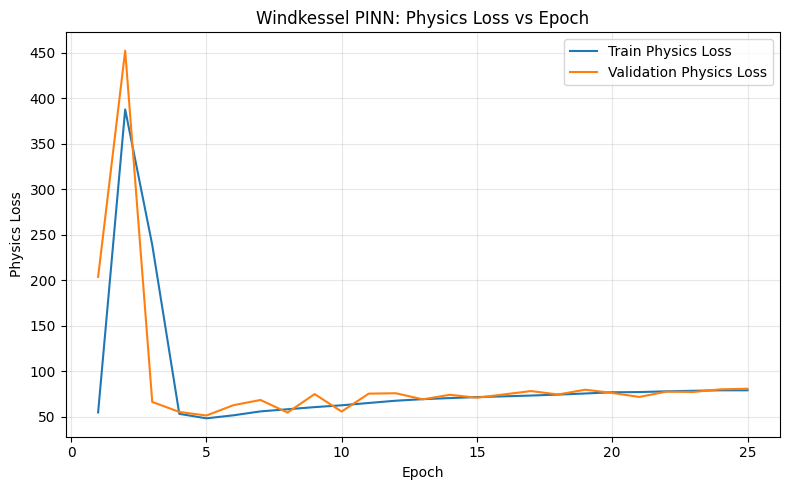

In [26]:
plot_pinn_training_metrics(
    results["history"],
    model_name="Windkessel PINN"
)

Epoch [001/50] | LR: 1.00e-04 | Train Total: 16098.0934 | Train SBP MSE: 13134.0637 | Train DBP MSE: 2963.9905 | Train Phys: 39.0808 | Train RMSE: SBP=114.604, DBP=54.443 | Val Total: 11542.4598 | Val SBP MSE: 9935.3207 | Val DBP MSE: 1607.0125 | Val Phys: 126.6709 | Val RMSE: SBP=99.676, DBP=40.088 | ✓
Epoch [002/50] | LR: 1.00e-04 | Train Total: 6573.5947 | Train SBP MSE: 5961.3633 | Train DBP MSE: 611.9021 | Train Phys: 329.2924 | Train RMSE: SBP=77.210, DBP=24.737 | Val Total: 3599.3275 | Val SBP MSE: 3422.2938 | Val DBP MSE: 176.6505 | Val Phys: 383.1852 | Val RMSE: SBP=58.500, DBP=13.291 | ✓
Epoch [003/50] | LR: 1.00e-04 | Train Total: 1405.9419 | Train SBP MSE: 1289.9894 | Train DBP MSE: 115.6963 | Train Phys: 256.2256 | Train RMSE: SBP=35.916, DBP=10.756 | Val Total: 524.8263 | Val SBP MSE: 375.3493 | Val DBP MSE: 149.3953 | Val Phys: 81.7119 | Val RMSE: SBP=19.374, DBP=12.223 | ✓
Epoch [004/50] | LR: 1.00e-04 | Train Total: 491.7589 | Train SBP MSE: 384.4926 | Train DBP MSE: 1

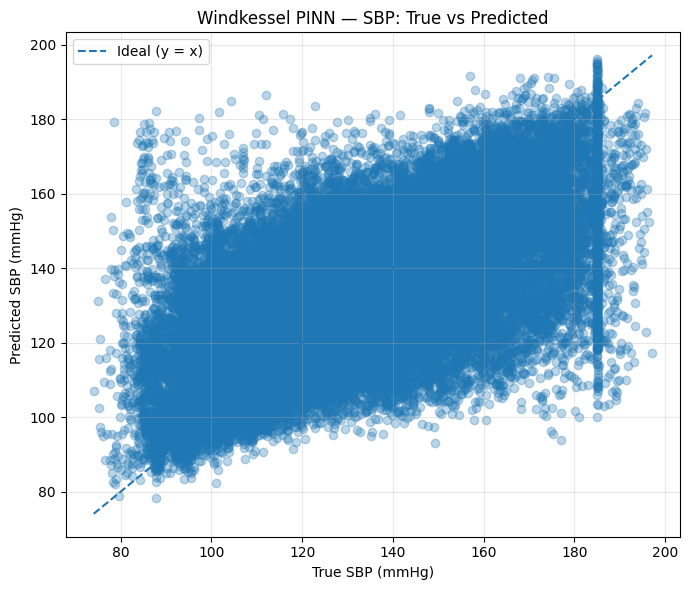

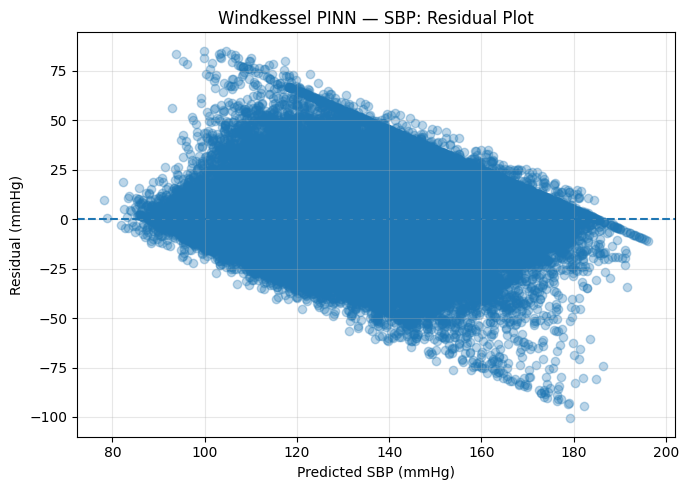

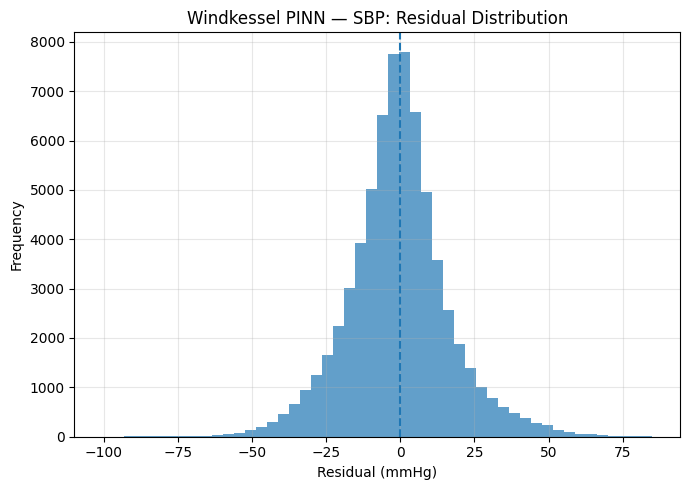

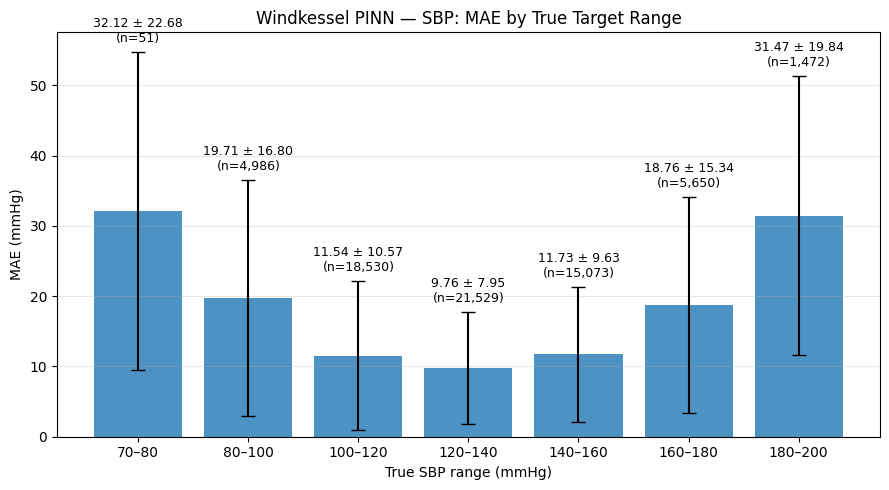


WINDKESSEL PINN — DBP TEST RESULTS
RMSE: 9.0371
MSE : 81.6696
R²  : 0.3415
MAE : 6.3266


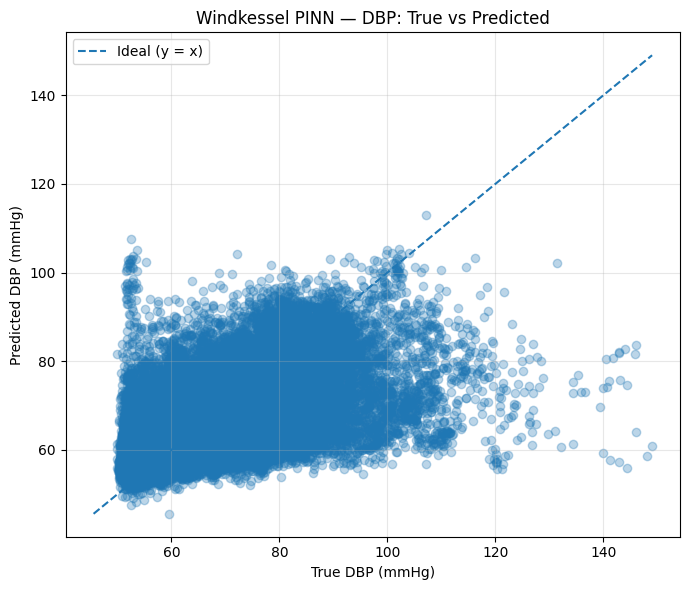

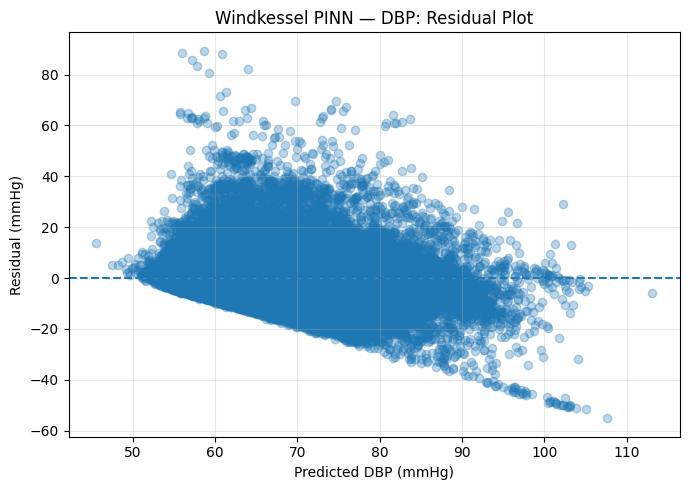

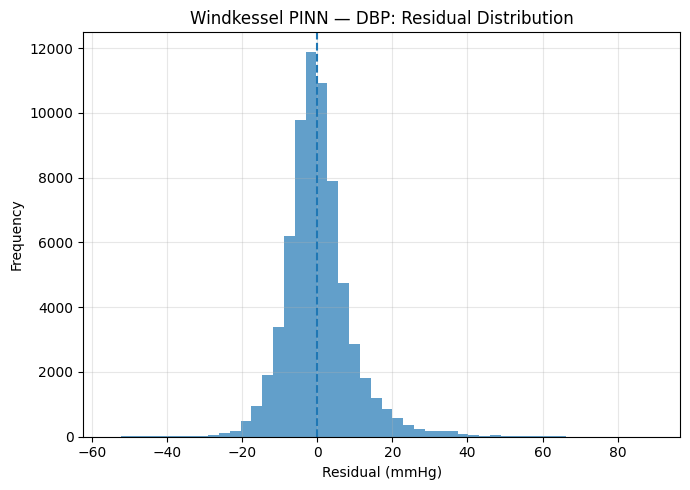

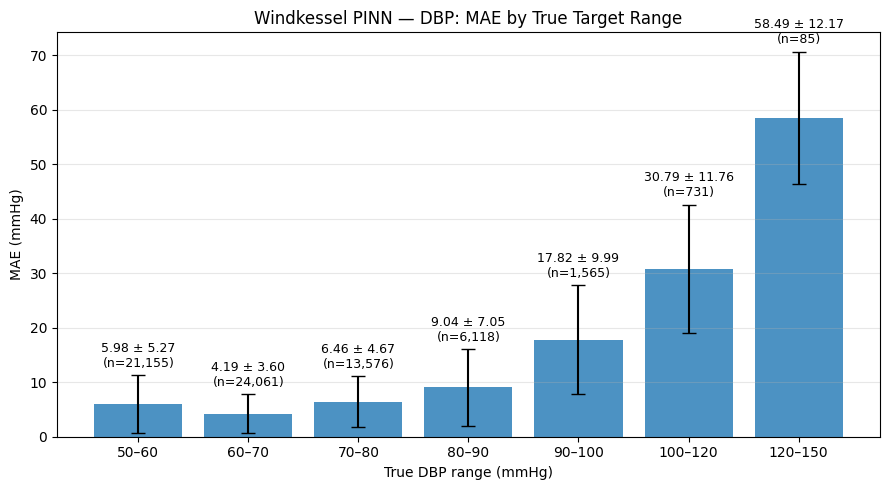

In [27]:
model, results = run_windkessel_pinn(
    X_train, y_train, delay_train,
    X_val, y_val, delay_val,
    X_test, y_test, delay_test,
    RC=RC,
    device=device,
    lambda_phys=0.001
)

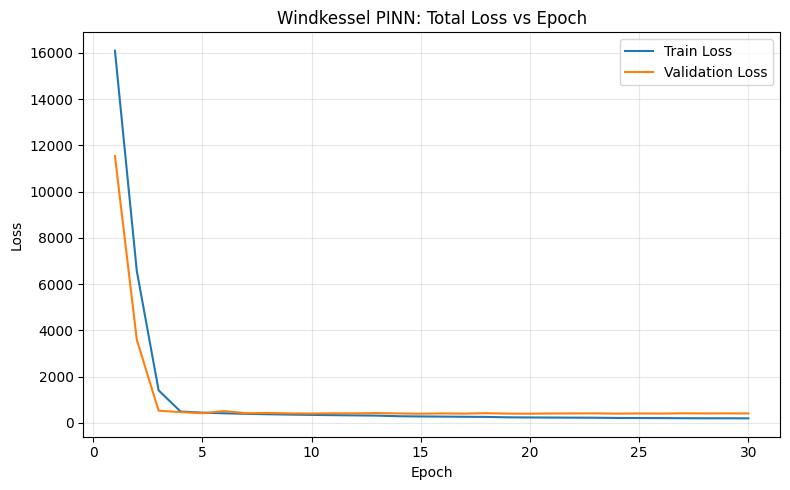

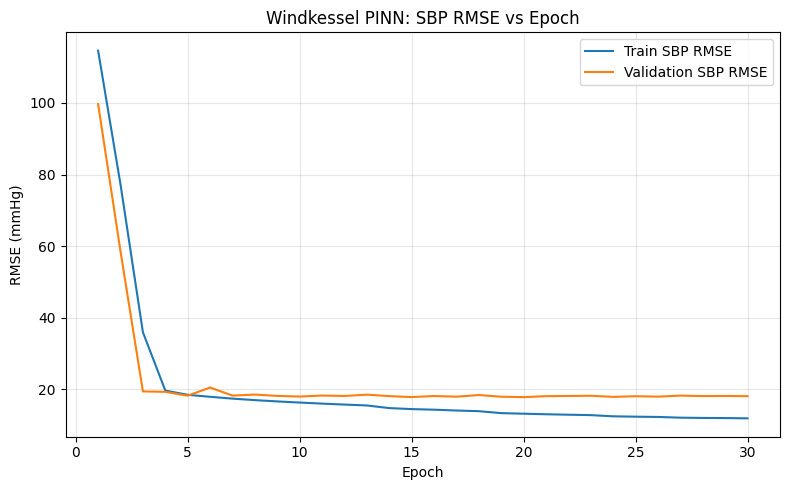

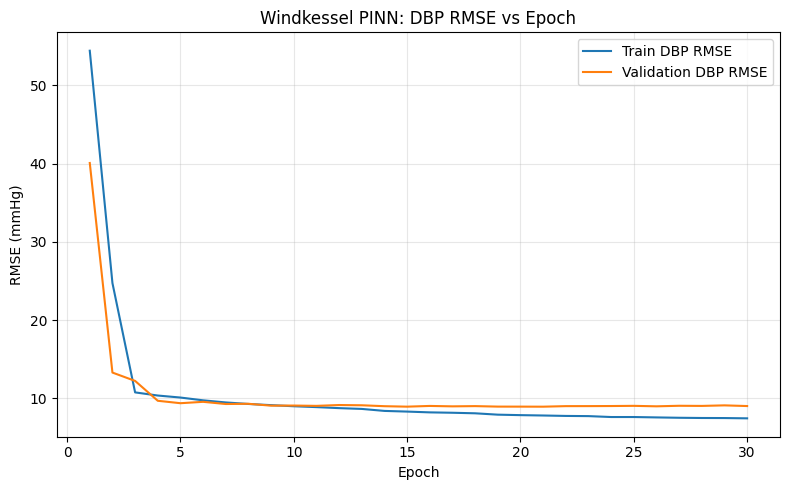

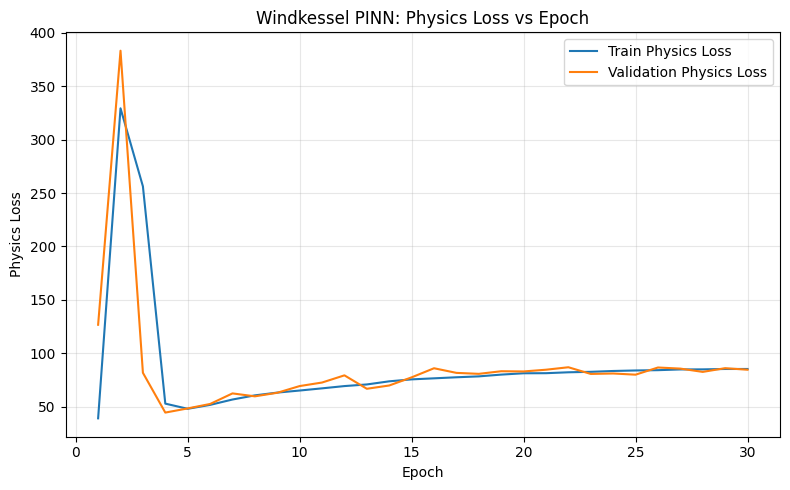

In [28]:
plot_pinn_training_metrics(
    results["history"],
    model_name="Windkessel PINN"
)

Epoch [001/50] | LR: 1.00e-04 | Train Total: 16027.2185 | Train SBP MSE: 13077.7306 | Train DBP MSE: 2949.0600 | Train Phys: 42.7904 | Train RMSE: SBP=114.358, DBP=54.305 | Val Total: 10759.6976 | Val SBP MSE: 9368.3281 | Val DBP MSE: 1389.7481 | Val Phys: 162.1385 | Val RMSE: SBP=96.790, DBP=37.279 | ✓
Epoch [002/50] | LR: 1.00e-04 | Train Total: 6503.0357 | Train SBP MSE: 5901.5505 | Train DBP MSE: 598.0838 | Train Phys: 340.1390 | Train RMSE: SBP=76.822, DBP=24.456 | Val Total: 2377.9893 | Val SBP MSE: 2245.2553 | Val DBP MSE: 127.4451 | Val Phys: 528.8962 | Val RMSE: SBP=47.384, DBP=11.289 | ✓
Epoch [003/50] | LR: 1.00e-04 | Train Total: 1387.0383 | Train SBP MSE: 1259.1131 | Train DBP MSE: 125.4926 | Train Phys: 243.2553 | Train RMSE: SBP=35.484, DBP=11.202 | Val Total: 514.1366 | Val SBP MSE: 414.7993 | Val DBP MSE: 98.5760 | Val Phys: 76.1272 | Val RMSE: SBP=20.367, DBP=9.929 | ✓
Epoch [004/50] | LR: 1.00e-04 | Train Total: 516.6742 | Train SBP MSE: 400.6312 | Train DBP MSE: 115

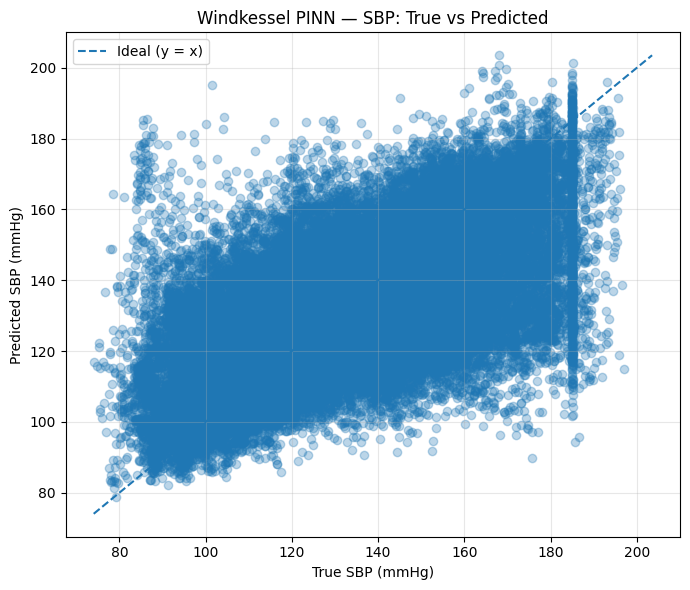

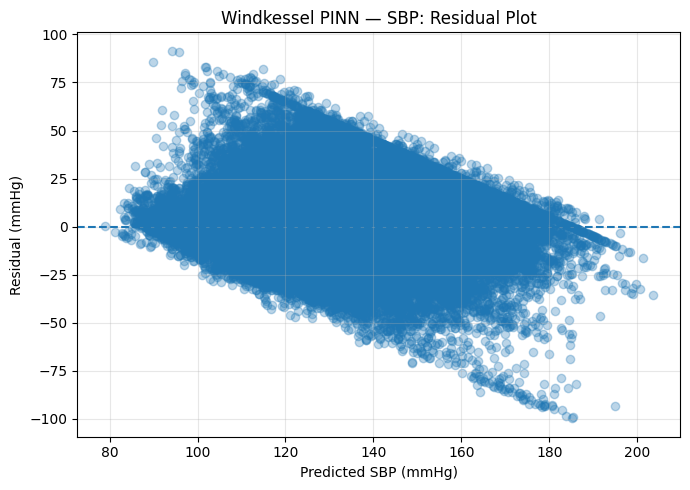

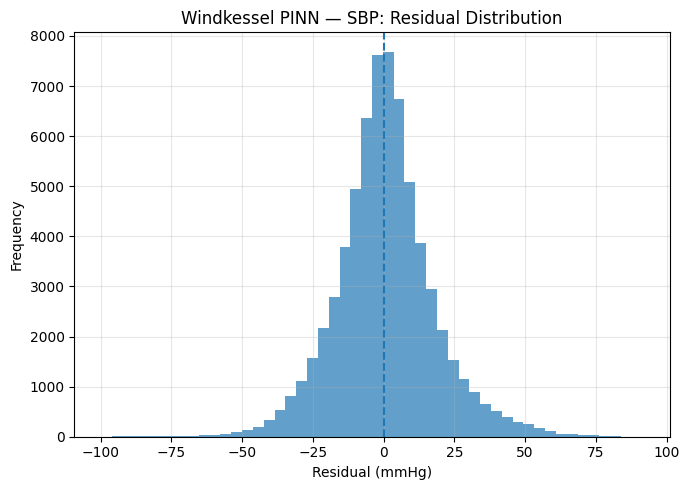

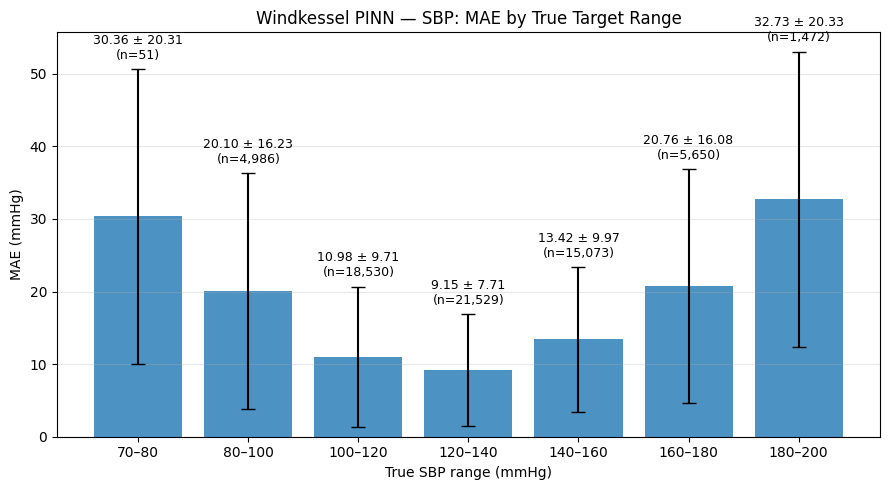


WINDKESSEL PINN — DBP TEST RESULTS
RMSE: 9.1467
MSE : 83.6626
R²  : 0.3255
MAE : 6.4325


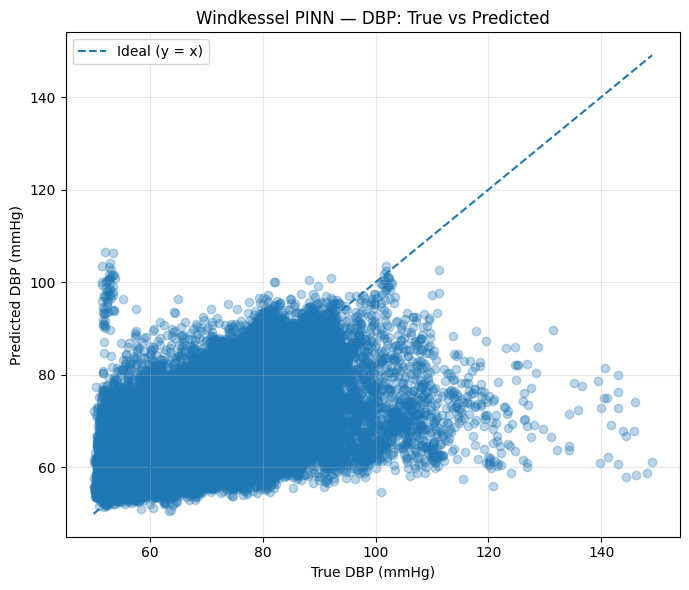

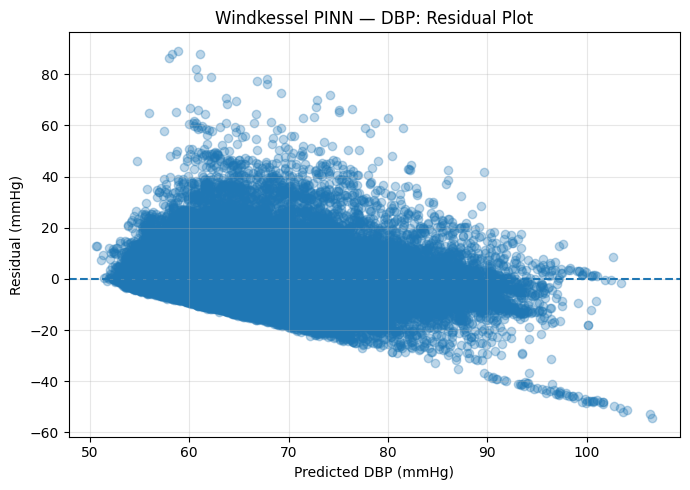

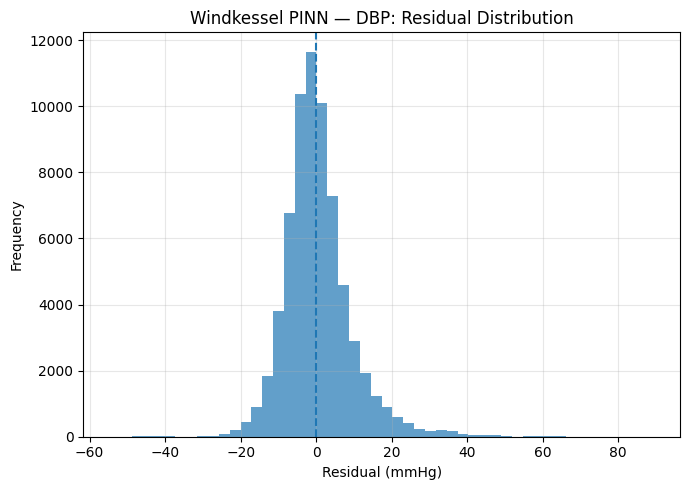

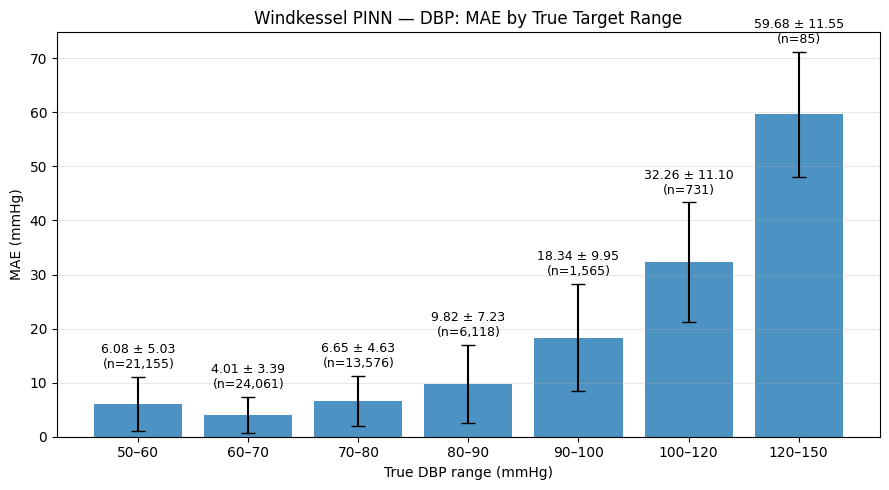

In [29]:
model, results = run_windkessel_pinn(
    X_train, y_train, delay_train,
    X_val, y_val, delay_val,
    X_test, y_test, delay_test,
    RC=RC,
    device=device,
    lambda_phys=0.01
)

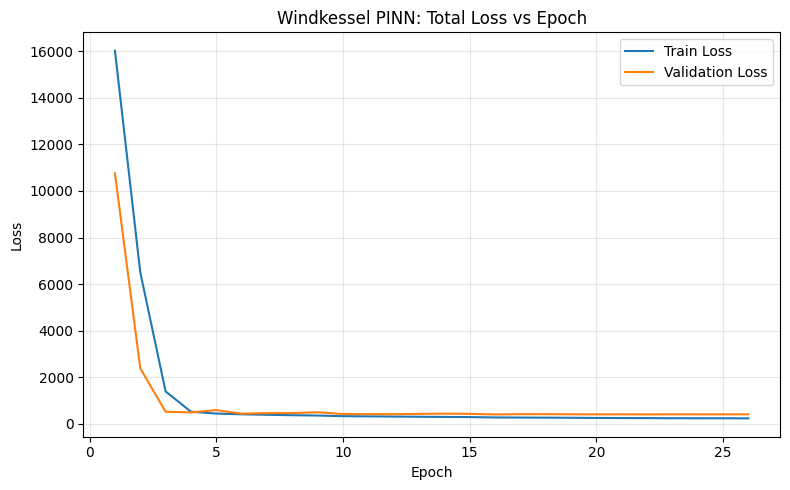

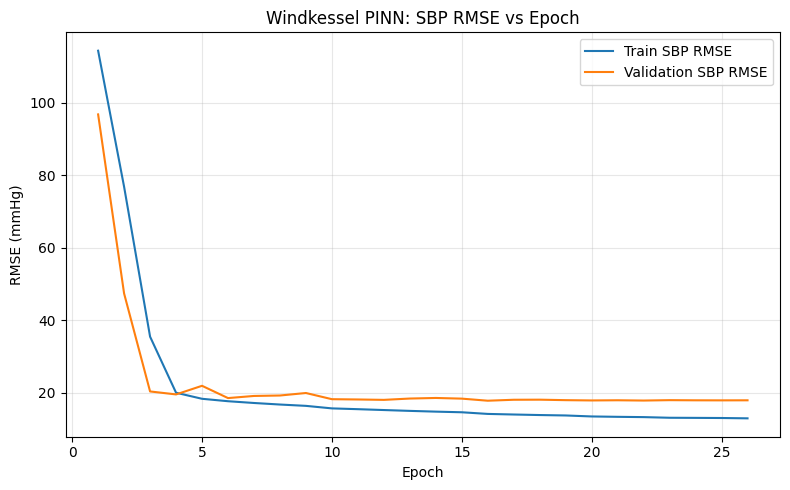

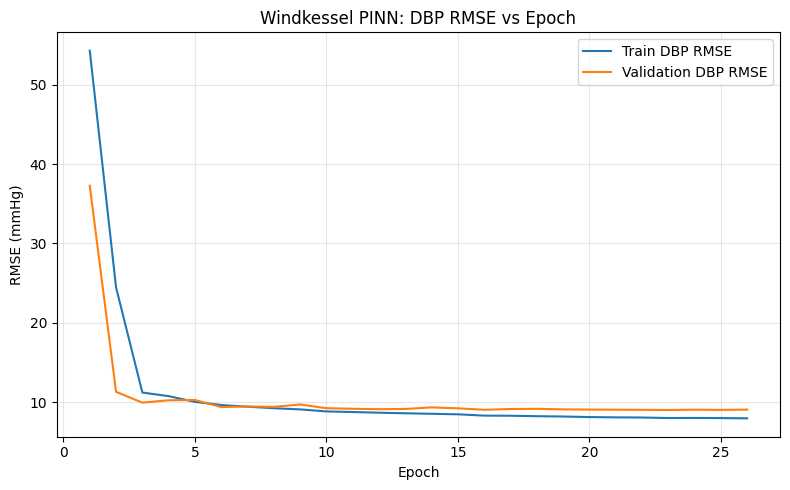

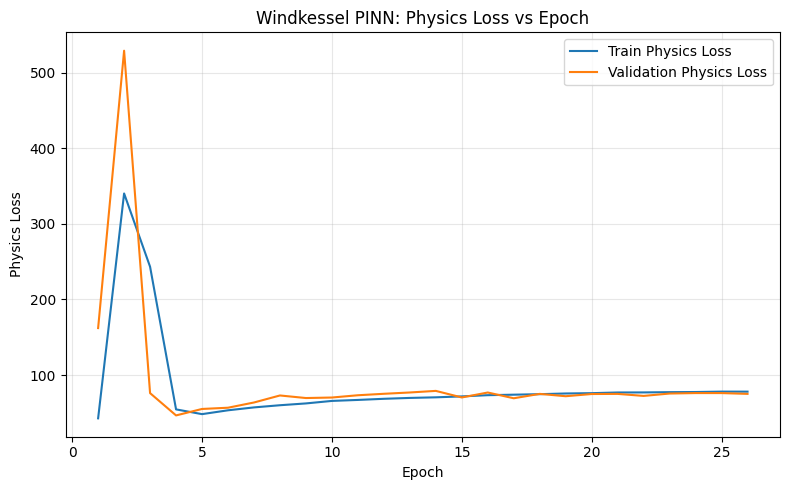

In [30]:
plot_pinn_training_metrics(
    results["history"],
    model_name="Windkessel PINN"
)

Epoch [001/50] | LR: 1.00e-04 | Train Total: 15689.6091 | Train SBP MSE: 12868.6660 | Train DBP MSE: 2816.0380 | Train Phys: 49.0513 | Train RMSE: SBP=113.440, DBP=53.066 | Val Total: 10701.3452 | Val SBP MSE: 9300.0961 | Val DBP MSE: 1385.5063 | Val Phys: 157.4282 | Val RMSE: SBP=96.437, DBP=37.222 | ✓
Epoch [002/50] | LR: 1.00e-04 | Train Total: 6570.2134 | Train SBP MSE: 5933.9462 | Train DBP MSE: 604.0981 | Train Phys: 321.6906 | Train RMSE: SBP=77.032, DBP=24.578 | Val Total: 3122.9014 | Val SBP MSE: 2934.9033 | Val DBP MSE: 146.4359 | Val Phys: 415.6217 | Val RMSE: SBP=54.175, DBP=12.101 | ✓
Epoch [003/50] | LR: 1.00e-04 | Train Total: 1450.1640 | Train SBP MSE: 1305.3515 | Train DBP MSE: 123.3159 | Train Phys: 214.9664 | Train RMSE: SBP=36.130, DBP=11.105 | Val Total: 498.4691 | Val SBP MSE: 377.1743 | Val DBP MSE: 114.7735 | Val Phys: 65.2135 | Val RMSE: SBP=19.421, DBP=10.713 | ✓
Epoch [004/50] | LR: 1.00e-04 | Train Total: 524.7901 | Train SBP MSE: 408.3228 | Train DBP MSE: 1

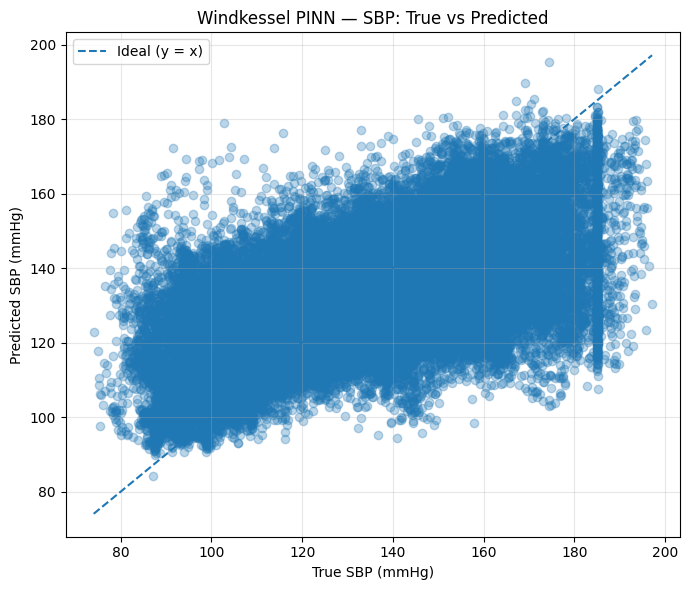

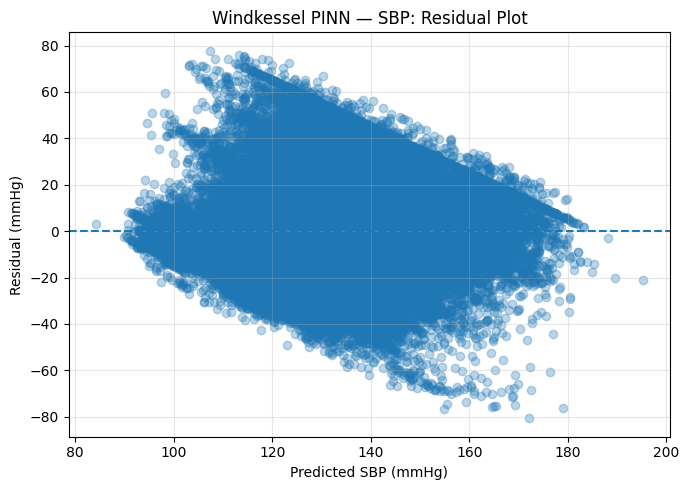

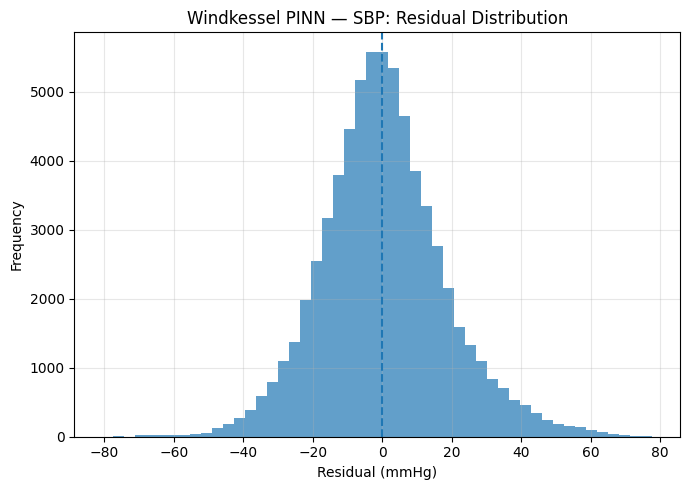

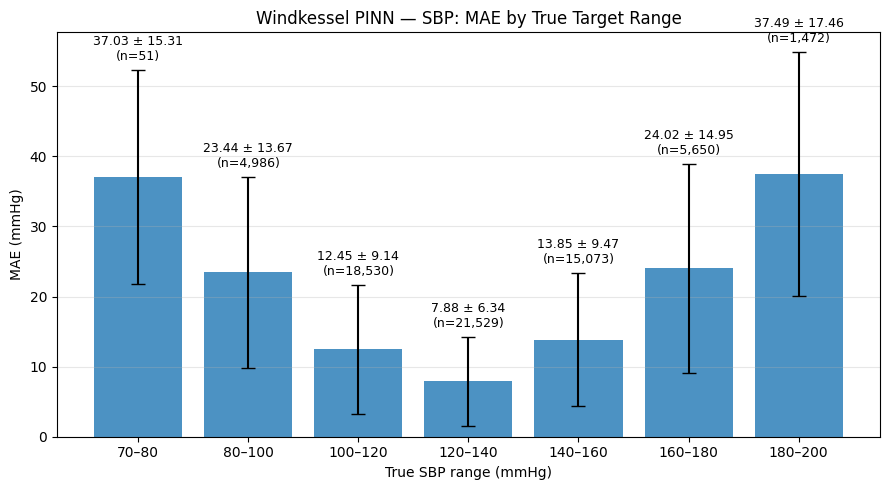


WINDKESSEL PINN — DBP TEST RESULTS
RMSE: 9.3933
MSE : 88.2345
R²  : 0.2886
MAE : 6.9334


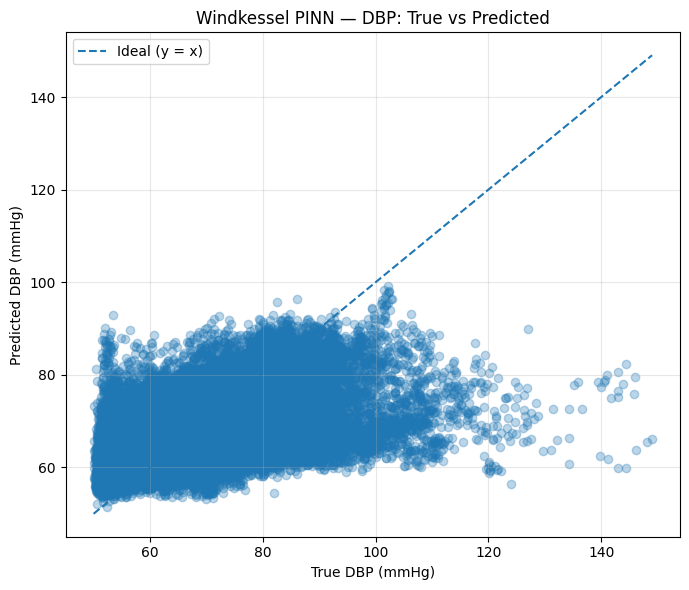

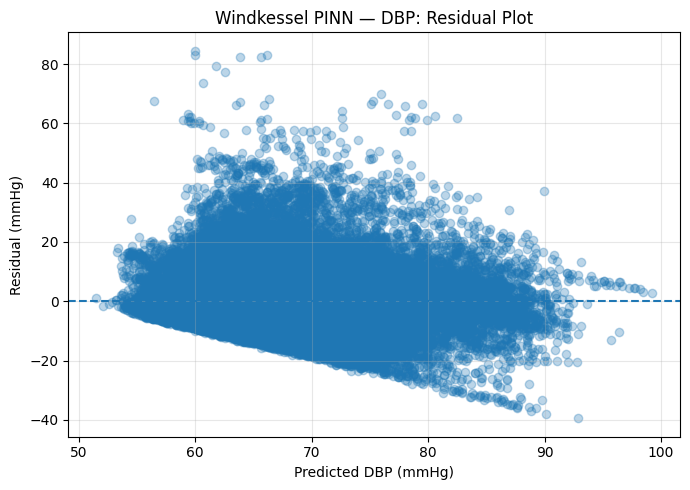

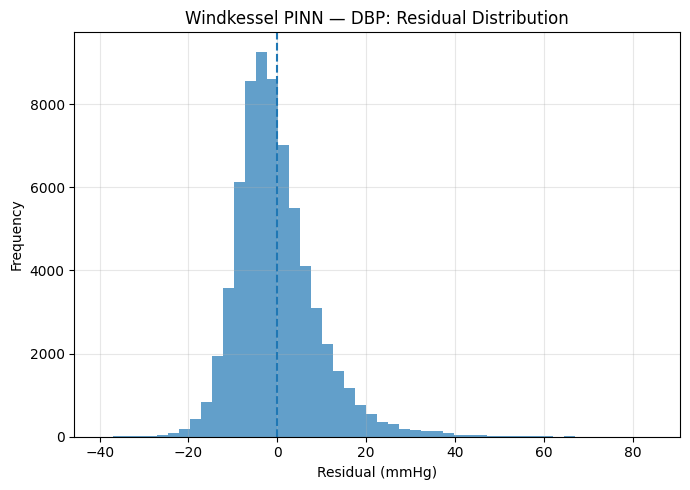

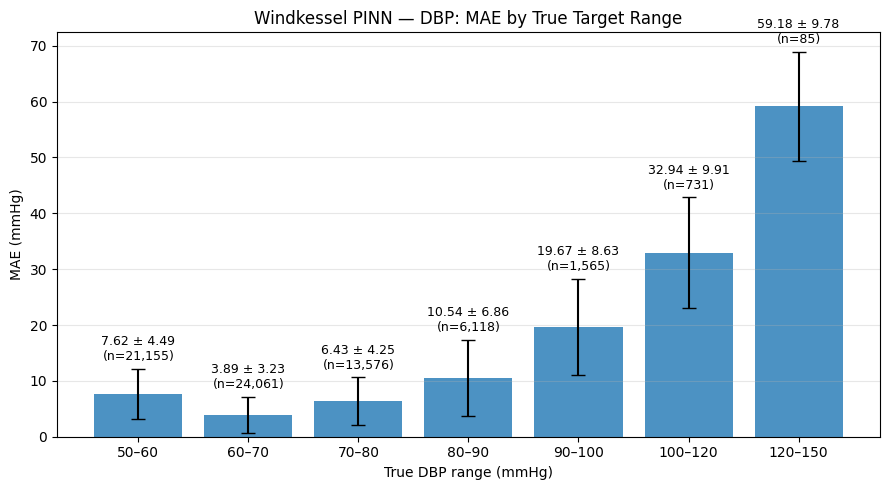

In [31]:
model, results = run_windkessel_pinn(
    X_train, y_train, delay_train,
    X_val, y_val, delay_val,
    X_test, y_test, delay_test,
    RC=RC,
    device=device,
    lambda_phys=0.1
)

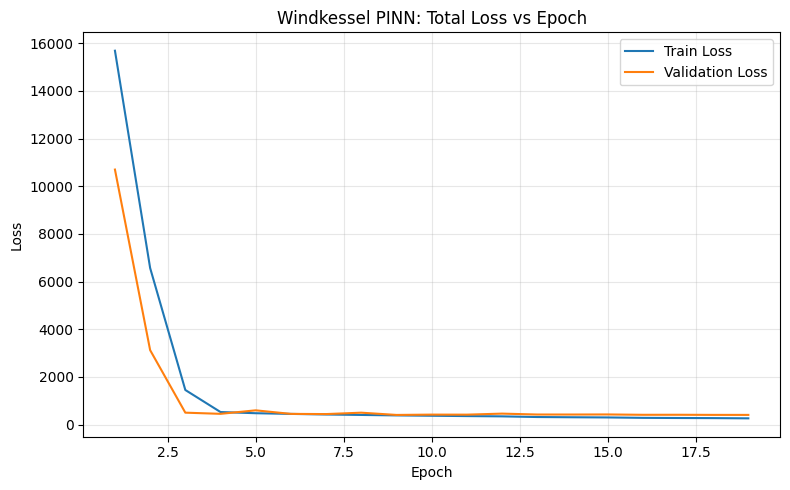

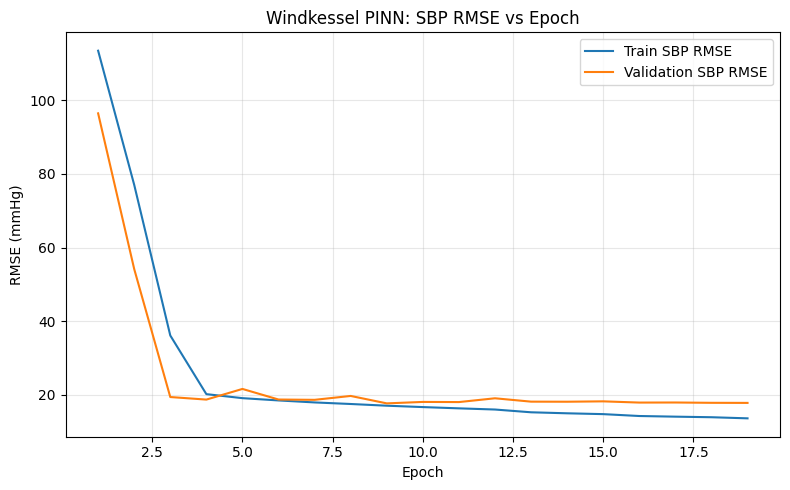

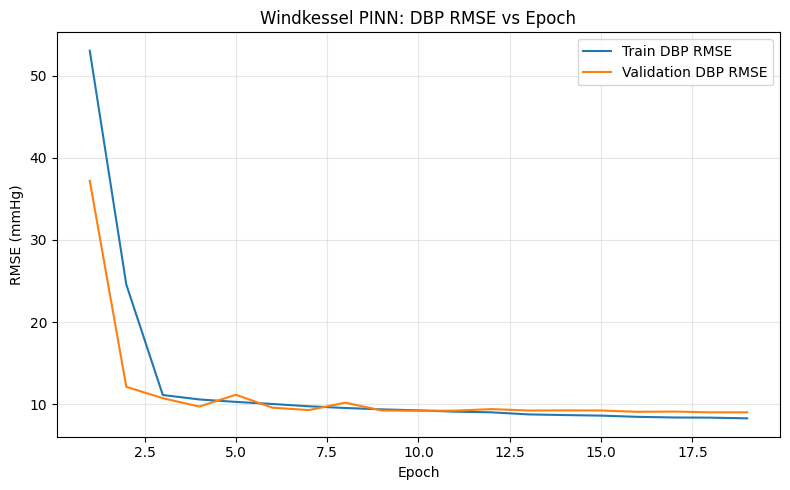

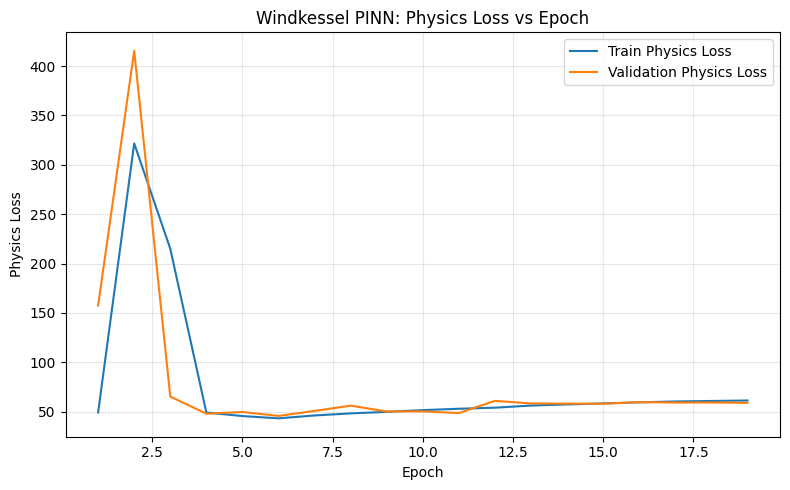

In [32]:
plot_pinn_training_metrics(
    results["history"],
    model_name="Windkessel PINN"
)

Epoch [001/50] | LR: 1.00e-04 | Train Total: 15485.9354 | Train SBP MSE: 12581.2674 | Train DBP MSE: 2870.9535 | Train Phys: 33.7144 | Train RMSE: SBP=112.166, DBP=53.581 | Val Total: 11127.6238 | Val SBP MSE: 9405.4616 | Val DBP MSE: 1627.6472 | Val Phys: 94.5150 | Val RMSE: SBP=96.982, DBP=40.344 | ✓
Epoch [002/50] | LR: 1.00e-04 | Train Total: 6352.8356 | Train SBP MSE: 5442.4362 | Train DBP MSE: 760.9462 | Train Phys: 149.4532 | Train RMSE: SBP=73.773, DBP=27.585 | Val Total: 3201.3237 | Val SBP MSE: 2753.8452 | Val DBP MSE: 337.8598 | Val Phys: 109.6187 | Val RMSE: SBP=52.477, DBP=18.381 | ✓
Epoch [003/50] | LR: 1.00e-04 | Train Total: 1399.5826 | Train SBP MSE: 1143.7263 | Train DBP MSE: 183.9603 | Train Phys: 71.8960 | Train RMSE: SBP=33.819, DBP=13.563 | Val Total: 528.9076 | Val SBP MSE: 384.0087 | Val DBP MSE: 101.1509 | Val Phys: 43.7481 | Val RMSE: SBP=19.596, DBP=10.057 | ✓
Epoch [004/50] | LR: 1.00e-04 | Train Total: 545.9049 | Train SBP MSE: 397.3465 | Train DBP MSE: 115

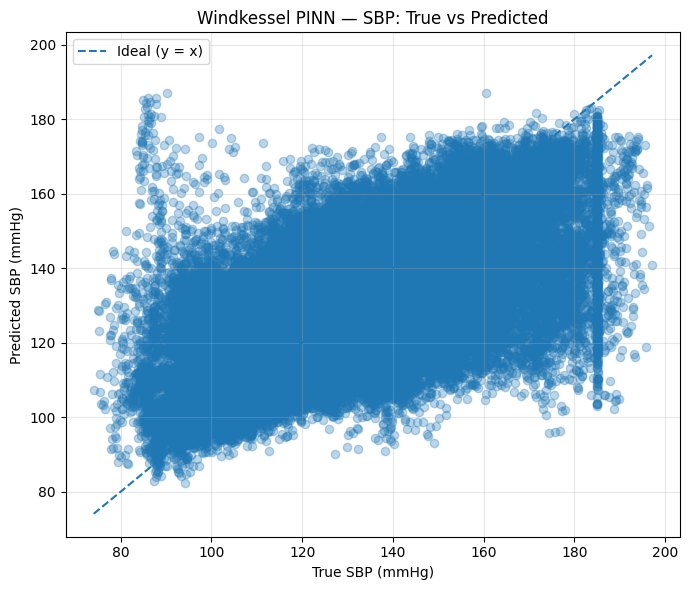

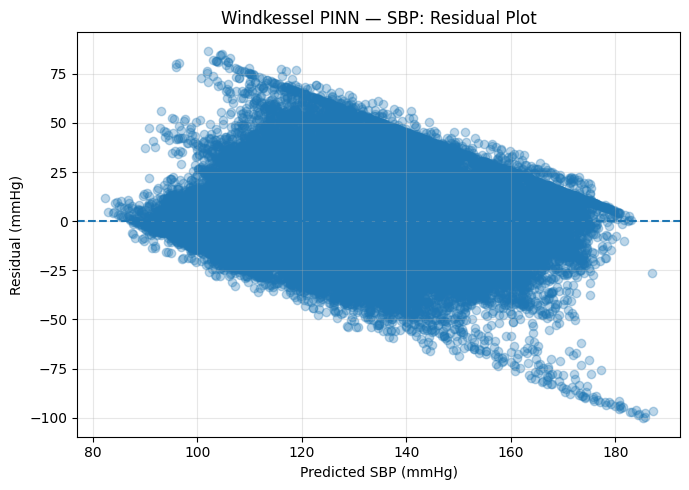

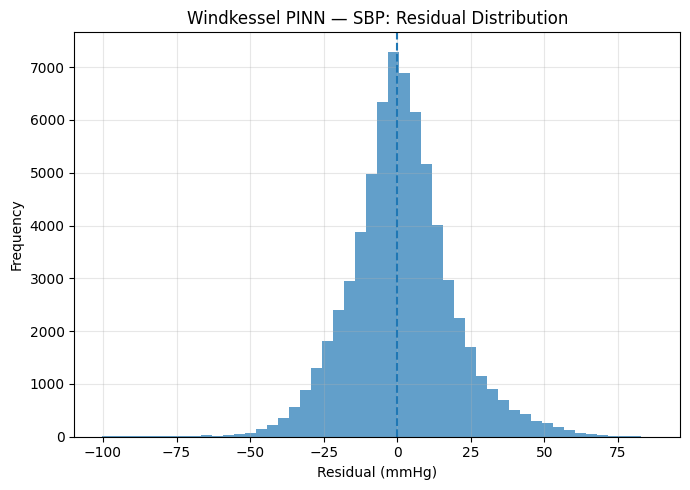

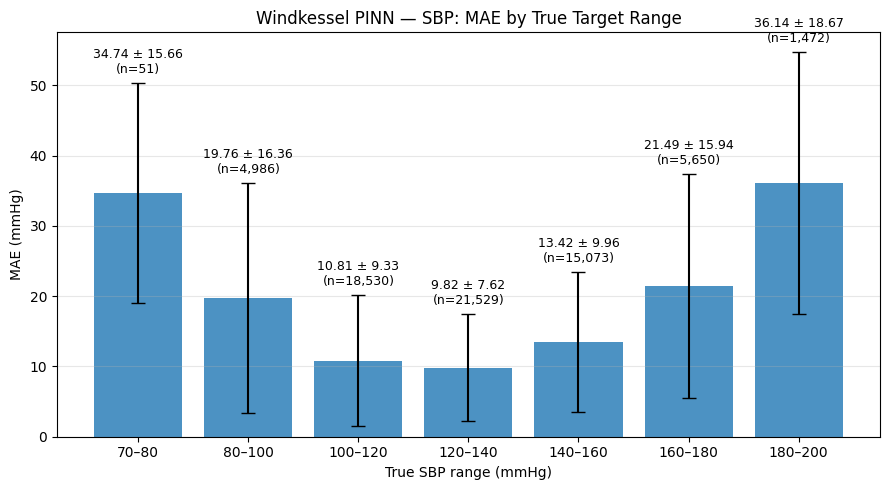


WINDKESSEL PINN — DBP TEST RESULTS
RMSE: 9.8219
MSE : 96.4706
R²  : 0.2222
MAE : 7.2066


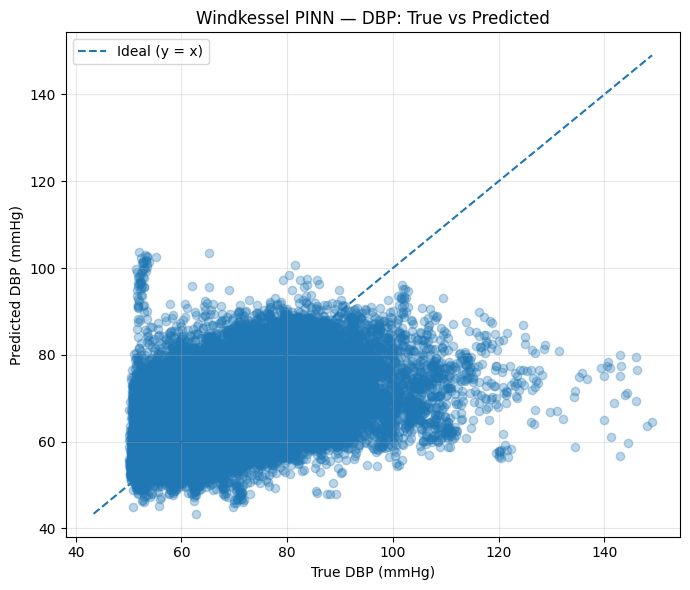

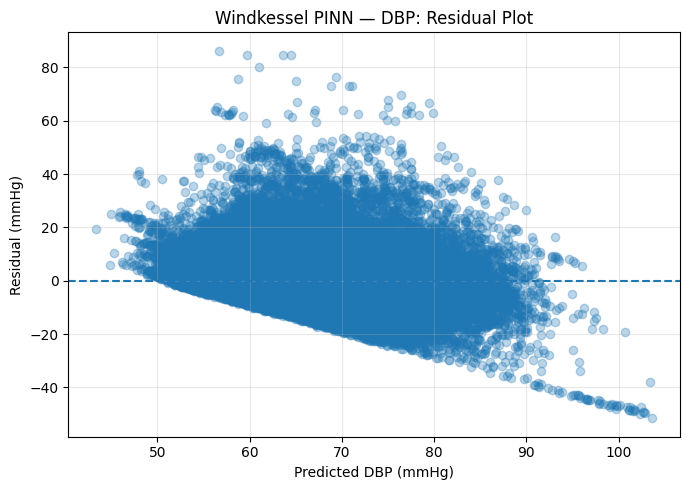

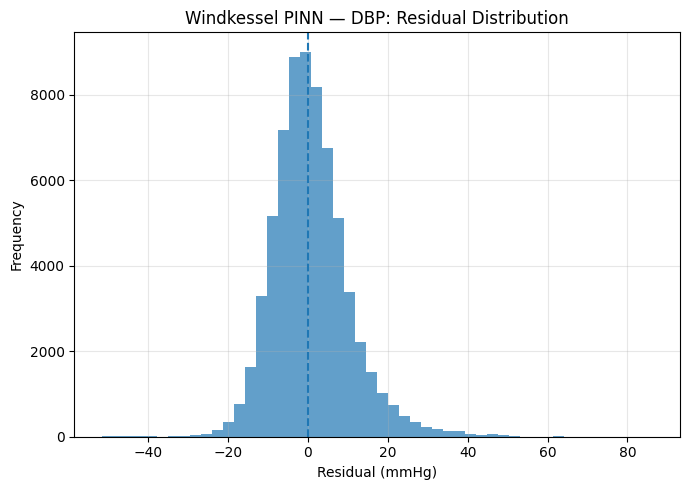

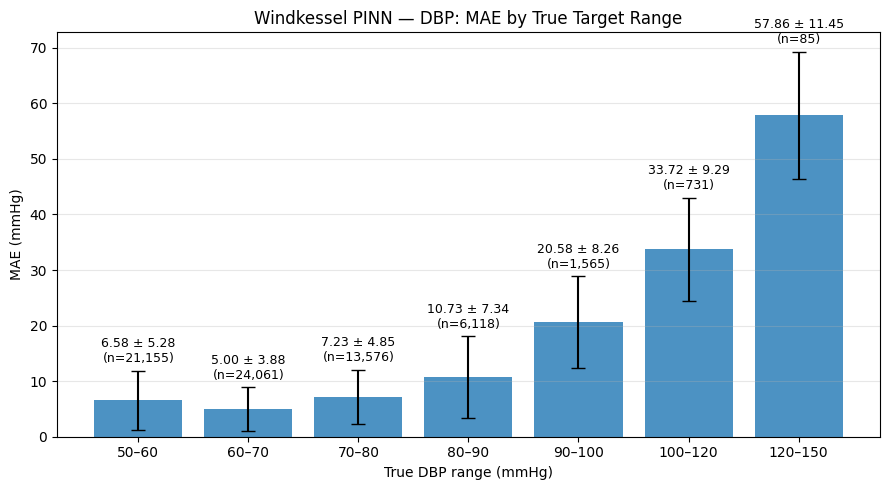

In [33]:
model, results = run_windkessel_pinn(
    X_train, y_train, delay_train,
    X_val, y_val, delay_val,
    X_test, y_test, delay_test,
    RC=RC,
    device=device,
    lambda_phys=1
)

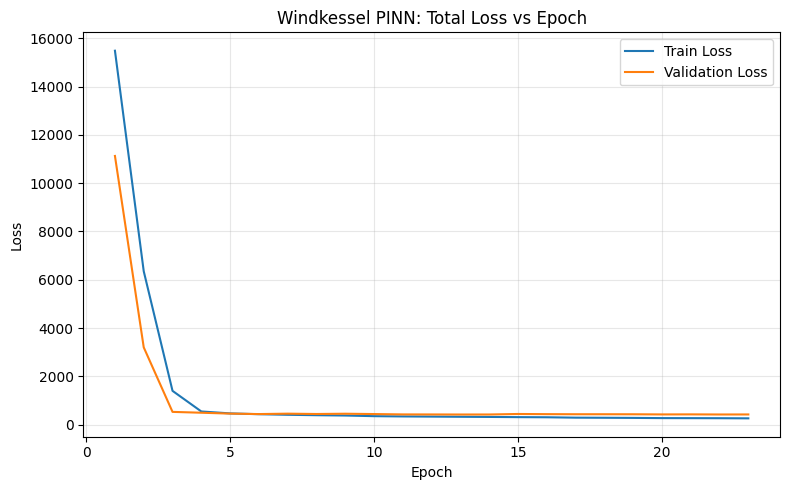

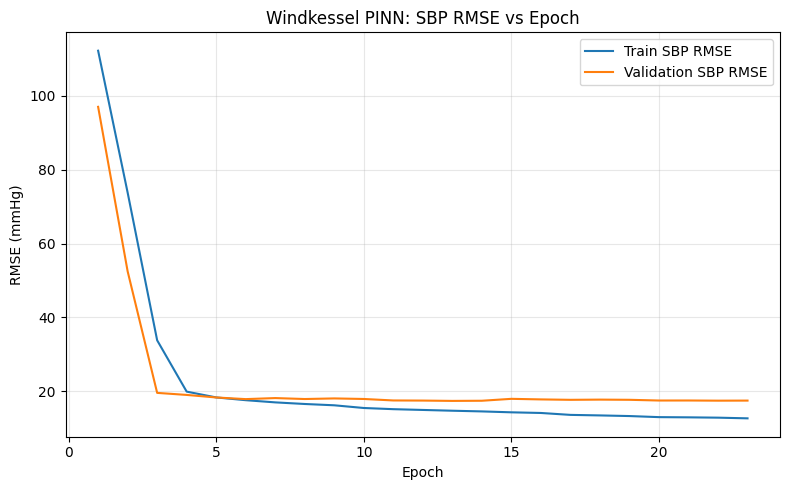

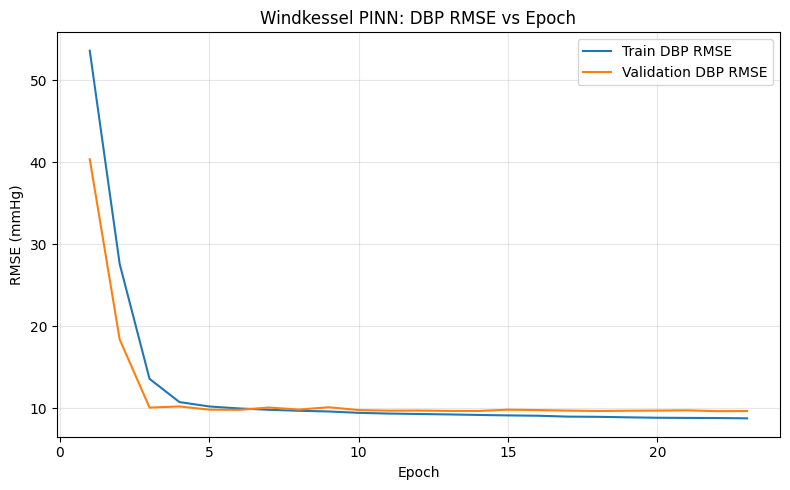

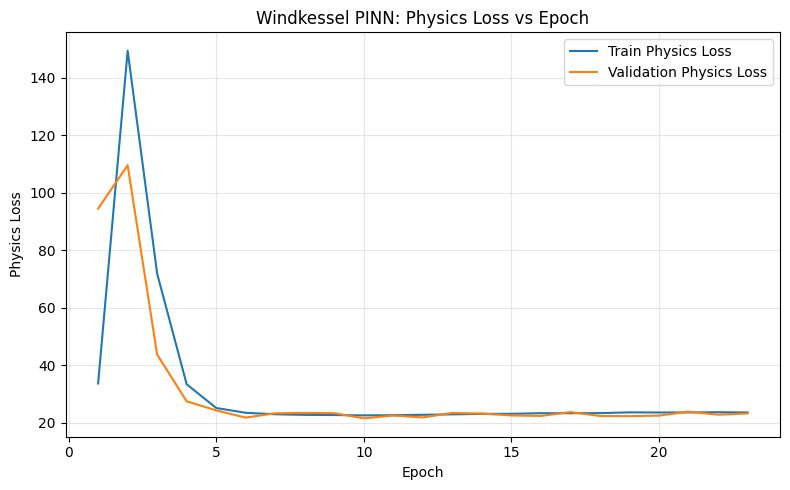

In [34]:
plot_pinn_training_metrics(
    results["history"],
    model_name="Windkessel PINN"
)

Epoch [001/50] | LR: 1.00e-04 | Train Total: 16016.6525 | Train SBP MSE: 12818.7397 | Train DBP MSE: 3109.6701 | Train Phys: 8.8243 | Train RMSE: SBP=113.220, DBP=55.764 | Val Total: 11405.7651 | Val SBP MSE: 9181.9185 | Val DBP MSE: 2047.9554 | Val Phys: 17.5891 | Val RMSE: SBP=95.822, DBP=45.254 | ✓
Epoch [002/50] | LR: 1.00e-04 | Train Total: 7340.1484 | Train SBP MSE: 5832.8392 | Train DBP MSE: 1356.8738 | Train Phys: 15.0435 | Train RMSE: SBP=76.373, DBP=36.836 | Val Total: 3067.4882 | Val SBP MSE: 2375.8714 | Val DBP MSE: 538.2752 | Val Phys: 15.3342 | Val RMSE: SBP=48.743, DBP=23.201 | ✓
Epoch [003/50] | LR: 1.00e-04 | Train Total: 1692.7352 | Train SBP MSE: 1239.2269 | Train DBP MSE: 322.2010 | Train Phys: 13.1307 | Train RMSE: SBP=35.203, DBP=17.950 | Val Total: 753.0228 | Val SBP MSE: 454.1892 | Val DBP MSE: 157.2621 | Val Phys: 14.1572 | Val RMSE: SBP=21.312, DBP=12.540 | ✓
Epoch [004/50] | LR: 1.00e-04 | Train Total: 661.9160 | Train SBP MSE: 406.7689 | Train DBP MSE: 134.2

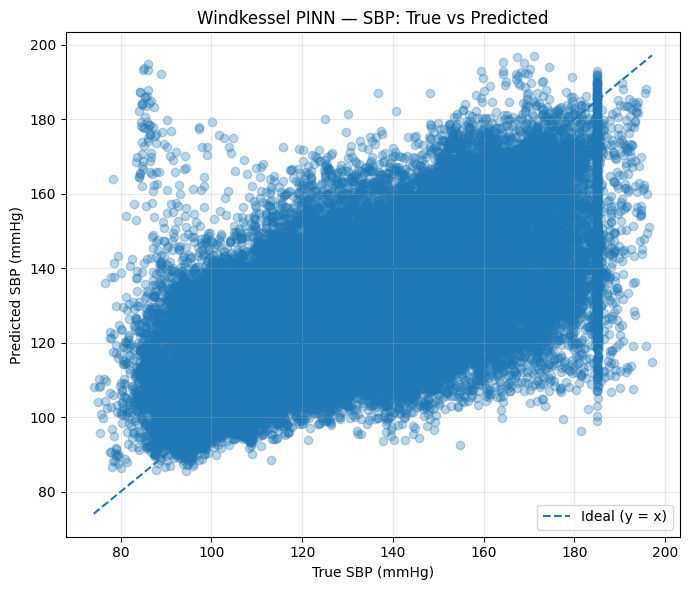

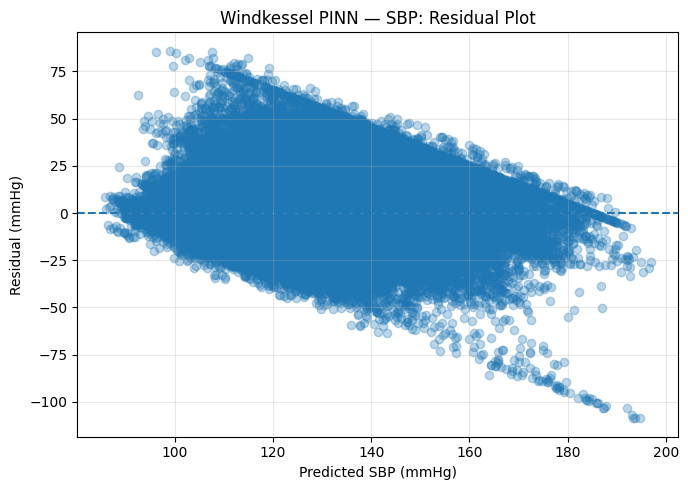

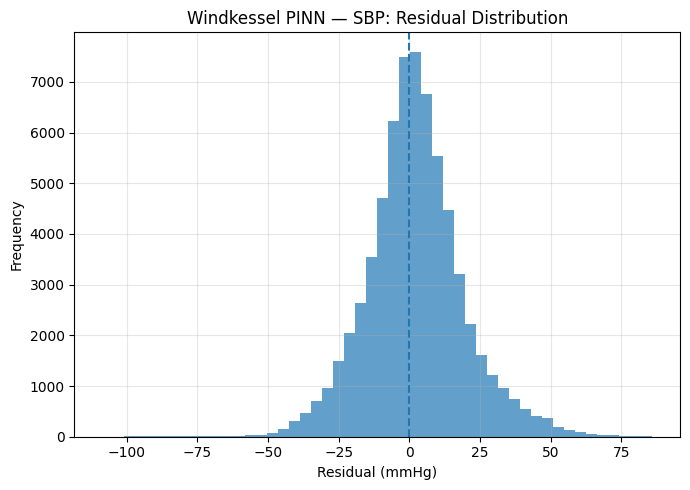

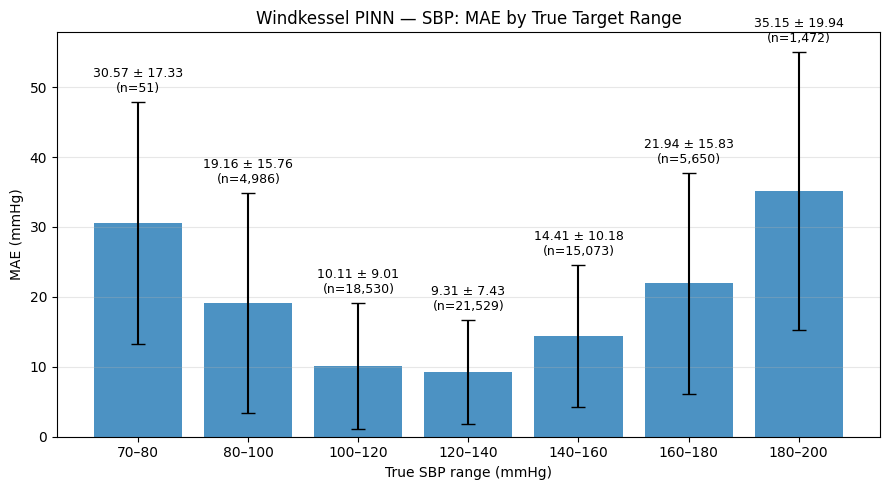


WINDKESSEL PINN — DBP TEST RESULTS
RMSE: 10.6712
MSE : 113.8741
R²  : 0.0819
MAE : 7.9288


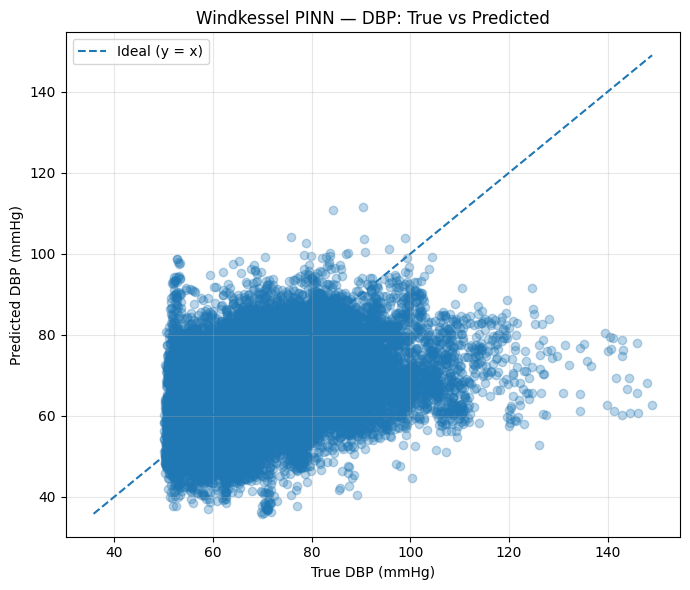

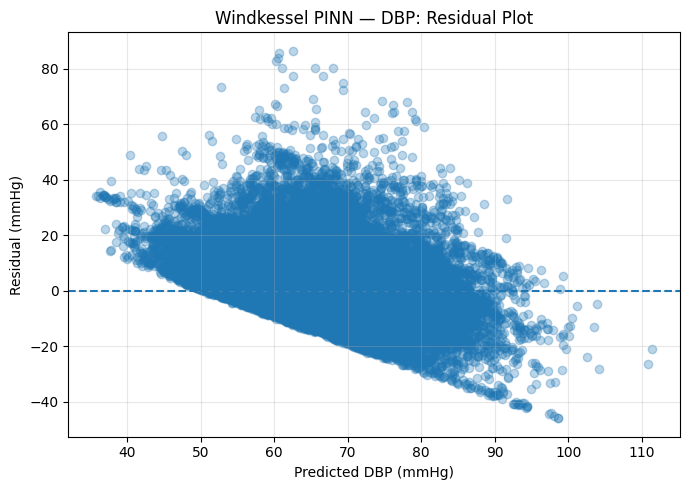

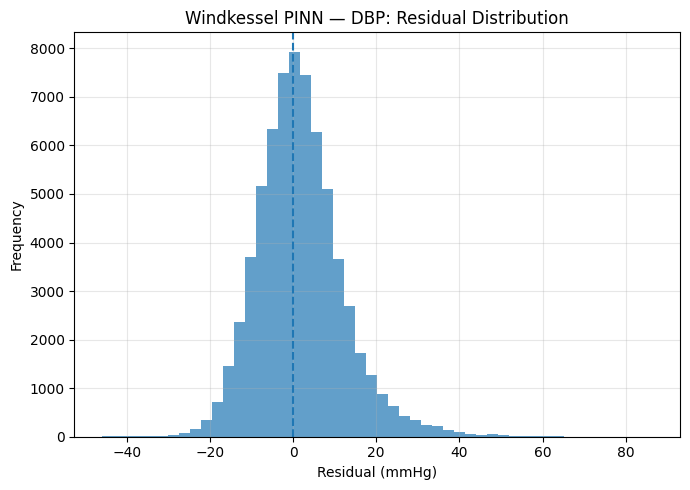

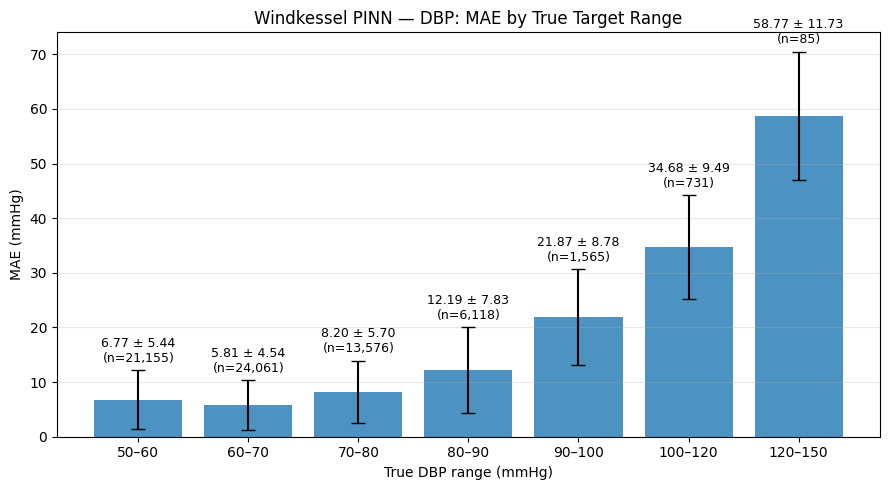

In [35]:
model, results = run_windkessel_pinn(
    X_train, y_train, delay_train,
    X_val, y_val, delay_val,
    X_test, y_test, delay_test,
    RC=RC,
    device=device,
    lambda_phys=10
)

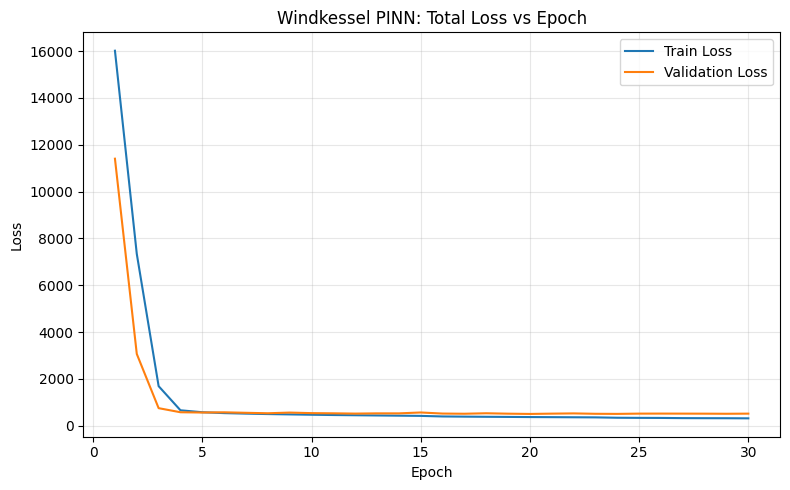

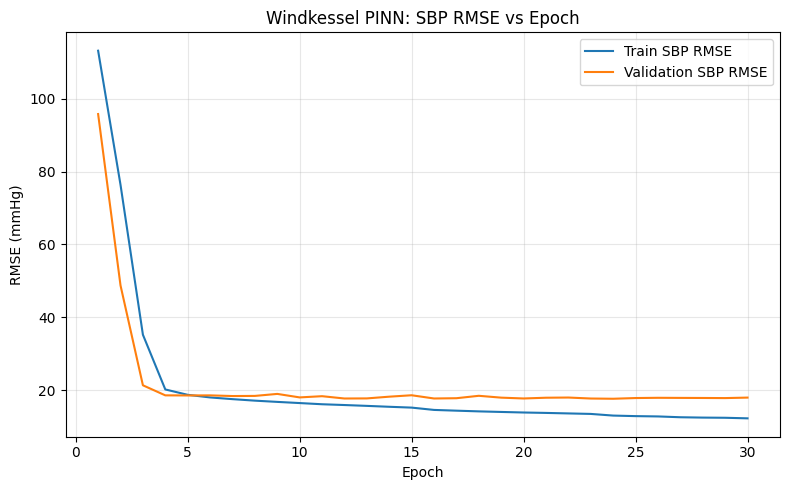

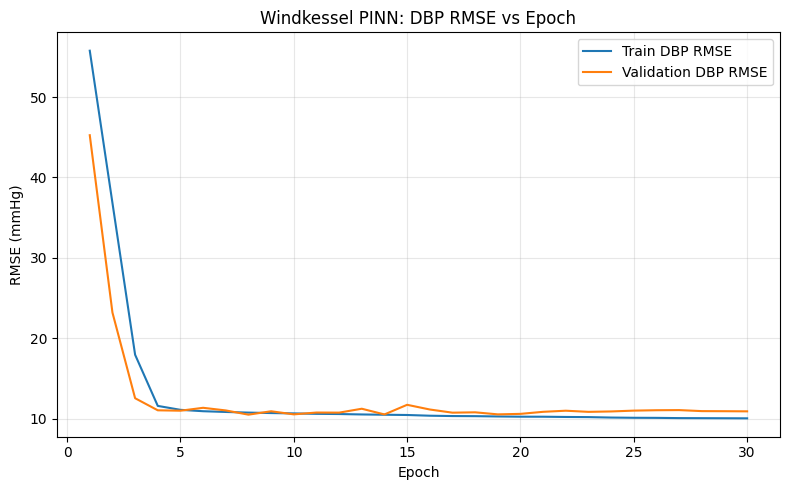

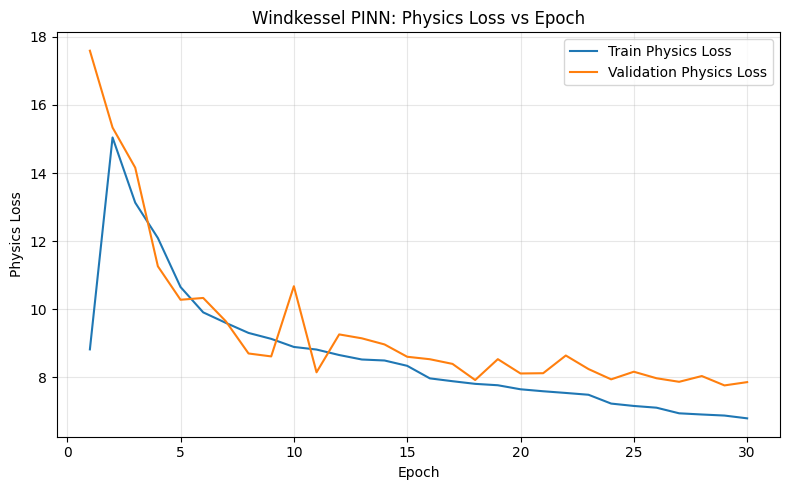

In [36]:
plot_pinn_training_metrics(
    results["history"],
    model_name="Windkessel PINN"
)

Epoch [001/50] | LR: 1.00e-04 | Train Total: 16666.0419 | Train SBP MSE: 13138.7465 | Train DBP MSE: 3415.5025 | Train Phys: 1.1179 | Train RMSE: SBP=114.624, DBP=58.442 | Val Total: 12062.9050 | Val SBP MSE: 9497.3708 | Val DBP MSE: 2392.8719 | Val Phys: 1.7266 | Val RMSE: SBP=97.454, DBP=48.917 | ✓
Epoch [002/50] | LR: 1.00e-04 | Train Total: 7990.8410 | Train SBP MSE: 6106.6218 | Train DBP MSE: 1610.5719 | Train Phys: 2.7365 | Train RMSE: SBP=78.145, DBP=40.132 | Val Total: 3900.1297 | Val SBP MSE: 2653.3139 | Val DBP MSE: 694.9853 | Val Phys: 5.5183 | Val RMSE: SBP=51.510, DBP=26.363 | ✓
Epoch [003/50] | LR: 1.00e-04 | Train Total: 2747.9419 | Train SBP MSE: 1747.2608 | Train DBP MSE: 496.6534 | Train Phys: 5.0403 | Train RMSE: SBP=41.800, DBP=22.286 | Val Total: 1844.5122 | Val SBP MSE: 881.6863 | Val DBP MSE: 228.9694 | Val Phys: 7.3386 | Val RMSE: SBP=29.693, DBP=15.132 | ✓
Epoch [004/50] | LR: 1.00e-04 | Train Total: 1481.0247 | Train SBP MSE: 654.3097 | Train DBP MSE: 215.3702

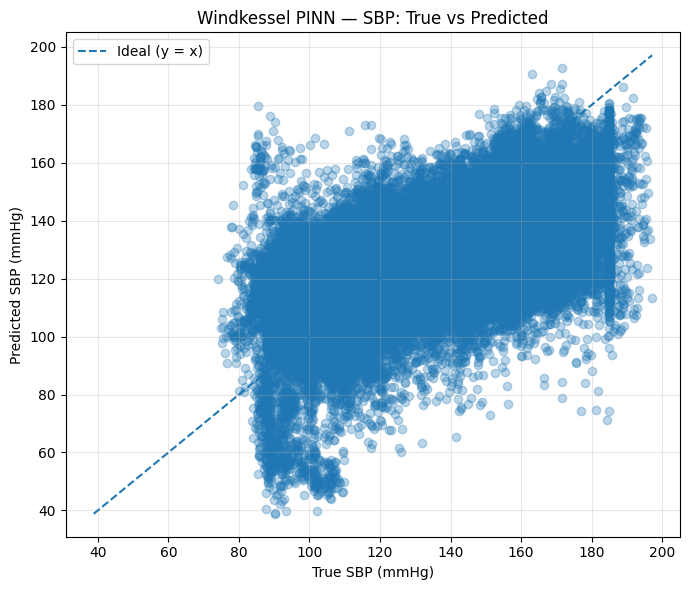

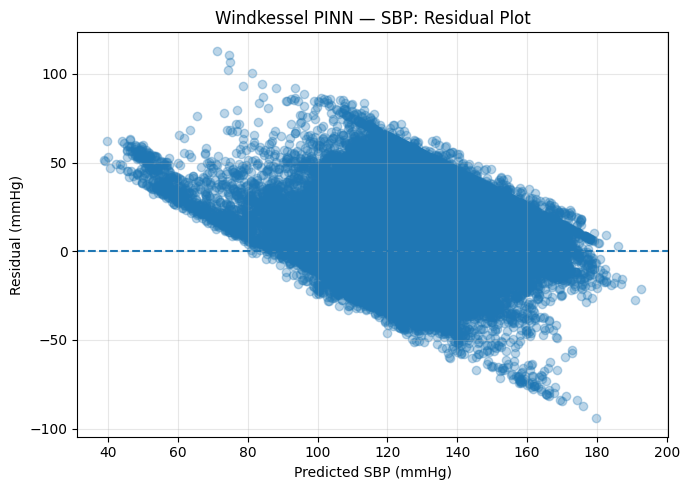

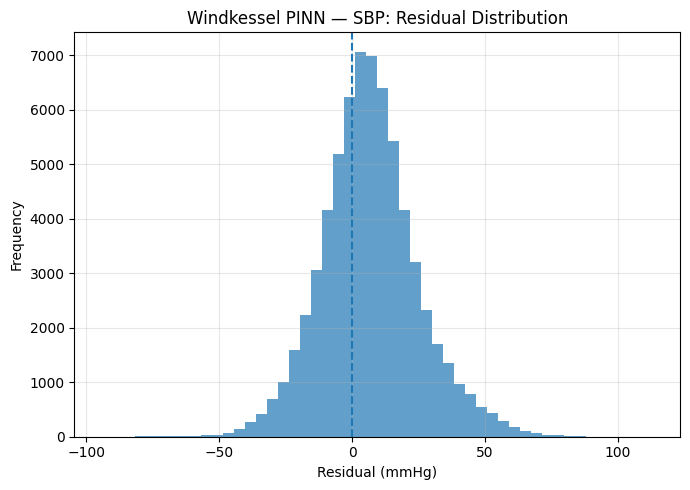

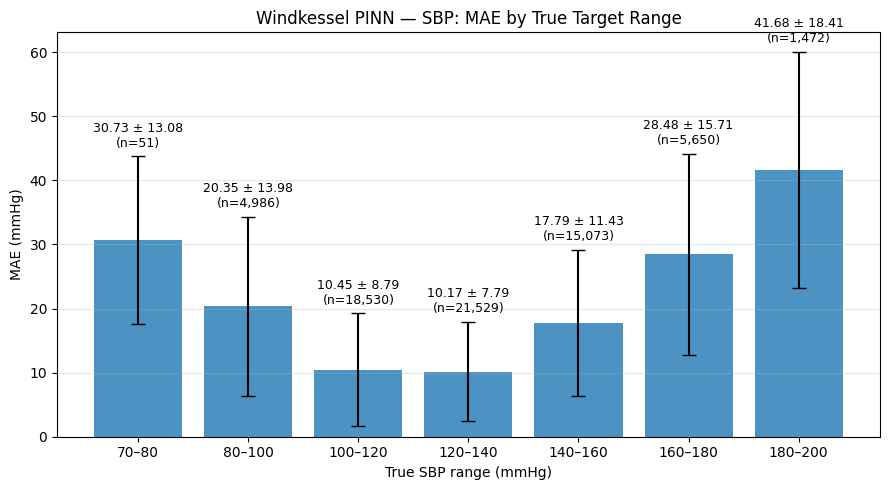


WINDKESSEL PINN — DBP TEST RESULTS
RMSE: 12.5479
MSE : 157.4501
R²  : -0.2695
MAE : 9.3077


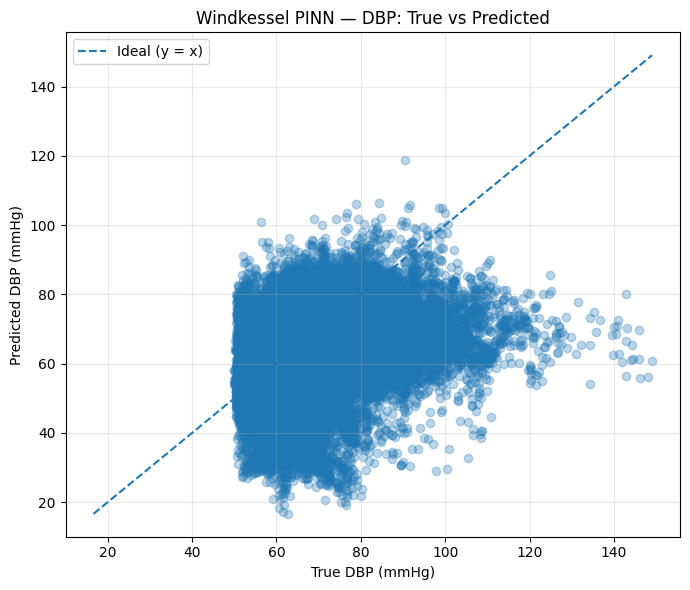

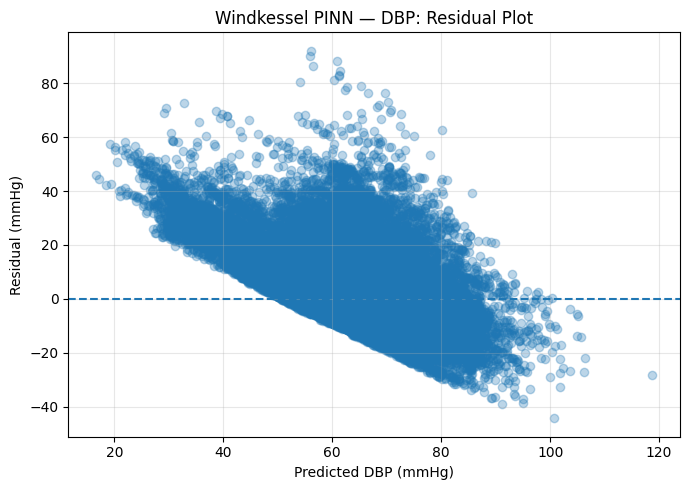

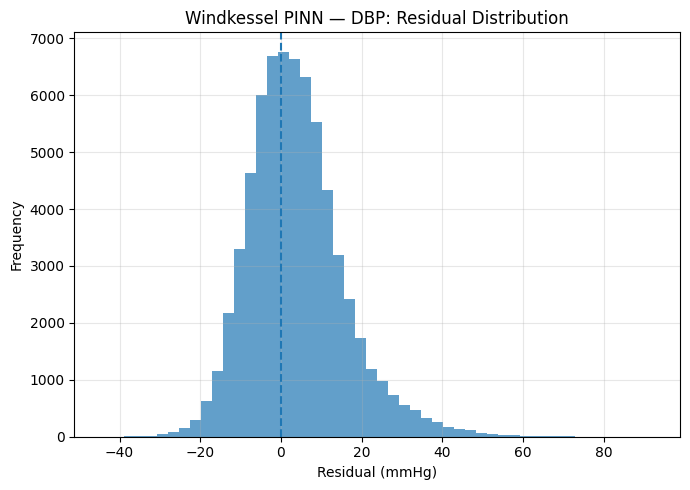

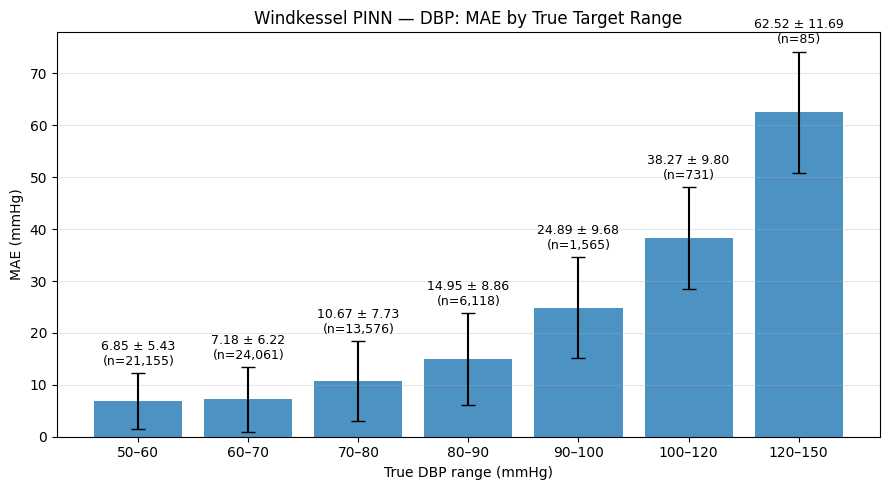

In [37]:
model, results = run_windkessel_pinn(
    X_train, y_train, delay_train,
    X_val, y_val, delay_val,
    X_test, y_test, delay_test,
    RC=RC,
    device=device,
    lambda_phys=100
)

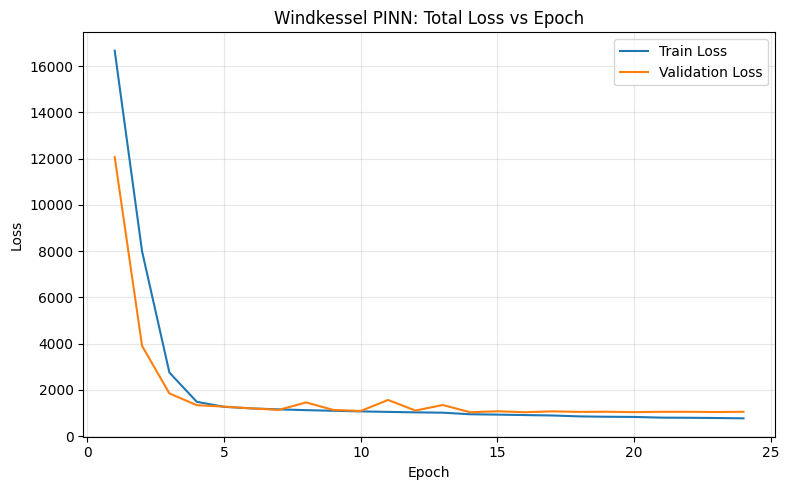

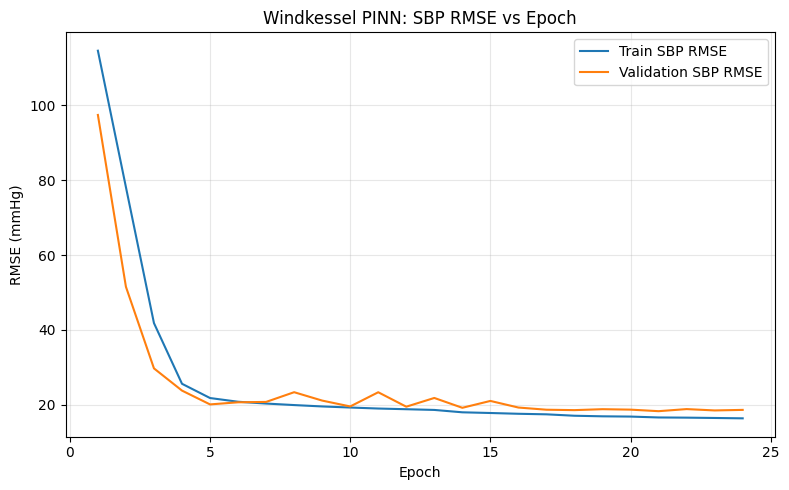

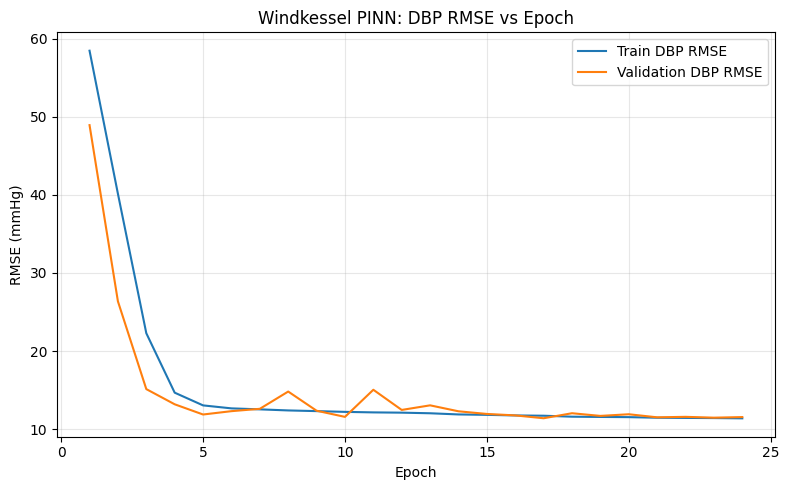

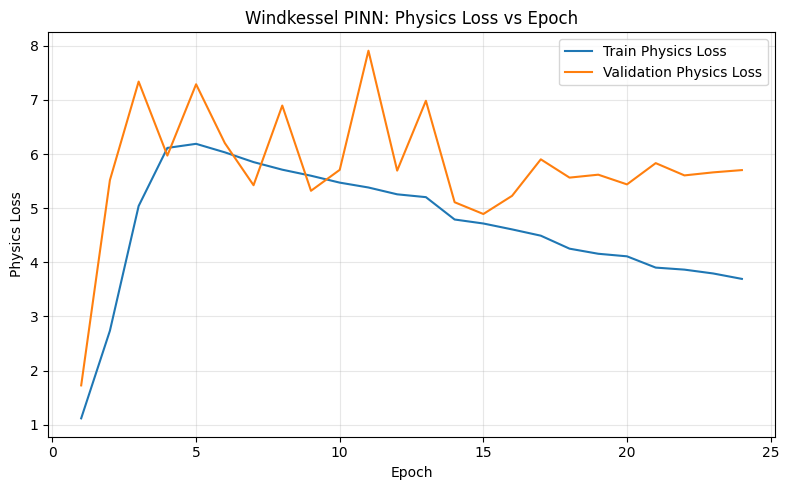

In [38]:
plot_pinn_training_metrics(
    results["history"],
    model_name="Windkessel PINN"
)